# <a id='toc1_'></a>[**An Analysis of Fish Data in the North East Texas and South East Oklahoma**](#toc0_)

> In this file I have combined all of the scripts, functions, and figures that I have found insightful or relevant towards the interpretation of this data.


---

**Table of contents**<a id='toc0_'></a>    
- [**An Analysis of Fish Data in the North East Texas and South East Oklahoma**](#toc1_)    
  - [Importing all of the Necessary Libraries](#toc1_1_)    
  - [Loading the Files as Pandas Data Frames & Global Vars](#toc1_2_)    
  - [Bar Plots](#toc1_3_)    
    - [Total Fish Species Bar Plot](#toc1_3_1_)    
    - [Total Fish Genus Bar Plot](#toc1_3_2_)    
    - [Total Population and Genus at Each Site](#toc1_3_3_)    
    - [Total Population and Genus at Each Site Ordered Bar Plot](#toc1_3_4_)    
    - [Site Attribute Bar Plots](#toc1_3_5_)    
      - [High t_population Sites](#toc1_3_5_1_)    
        - [Site #29 Bar Plots](#toc1_3_5_1_1_)    
        - [Site #4 Bar Plots](#toc1_3_5_1_2_)    
        - [Site #9 Bar Plots](#toc1_3_5_1_3_)    
        - [Site #43 Bar Plots](#toc1_3_5_1_4_)    
      - [Low t_population Sites](#toc1_3_5_2_)    
        - [Site #1 Bar Plots](#toc1_3_5_2_1_)    
        - [Site #18 Bar Plots](#toc1_3_5_2_2_)    
        - [Site #2 Bar Plots](#toc1_3_5_2_3_)    
        - [Site #17 Bar Plots](#toc1_3_5_2_4_)    
  - [Correlation Plots](#toc1_4_)    
    - [Correlation Heatmap](#toc1_4_1_)    
    - [Ranked Correlation Decay Plot](#toc1_4_2_)    
    - [Scatter TrendLine Plotter](#toc1_4_3_)    
      - [pH Scatter Plot](#toc1_4_3_1_)    
      - [upstreamCumDA_km2 Scatter Plot](#toc1_4_3_2_)    
      - [pb_Bedrock Scatter Plot](#toc1_4_3_3_)    
      - [pft_macrophytes  Scatter Plot](#toc1_4_3_4_)    
  - [Clustering Methods](#toc1_5_)    
    - [Clustering Sites by envAtt](#toc1_5_1_)    
  - [Classifiers](#toc1_6_)    
    - [KNN Classifier](#toc1_6_1_)    
  - [Regression Models](#toc1_7_)    
    - [t_population & t_genus Regressors](#toc1_7_1_)    
      - [Random Forrest Regressor](#toc1_7_1_1_)    
      - [XGBoost](#toc1_7_1_2_)    
    - [Site Genus Distribution Regressor](#toc1_7_2_)    
      - [X = Site Attributes](#toc1_7_2_1_)    
      - [X = Genus Distribution](#toc1_7_2_2_)    
      - [Fish Genus Correlation Heat Map](#toc1_7_2_3_)    
      - [X = Time Metrics](#toc1_7_2_4_)    
    - [Site Genus Presence Binary Regressors](#toc1_7_3_)    
      - [X = Site Attributes](#toc1_7_3_1_)    
      - [X = Genus Distribution](#toc1_7_3_2_)    
      - [X = Time Metrics](#toc1_7_3_3_)    
      - [X Value Comparison](#toc1_7_3_4_)    
  - [A Focus on Orange Belly Darters](#toc1_8_)    
    - [Etheostoma Radiosum Distribution](#toc1_8_1_)    
    - [Sites Attributes with High Orange Belly Darter Count](#toc1_8_2_)    
    - [Correlation Decay Plot With Site Attributes](#toc1_8_3_)    
    - [Specific Attribute Trend Lines](#toc1_8_4_)    
    - [U-MAP Clustering](#toc1_8_5_)    
    - [KNN Classifier](#toc1_8_6_)    
      - [First Model](#toc1_8_6_1_)    
      - [Determining the Best Parameters for the KNN](#toc1_8_6_2_)    
      - [Performing KNN With the Best Parameters](#toc1_8_6_3_)    
  - [A Focus on Nototropis](#toc1_9_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[Importing all of the Necessary Libraries](#toc0_)

> As I write this code, I will import **ALL** of the libraries I use in this cell

In [2]:
# ================================= Basic Dataframe and Visualization Libraries =================================

import pandas as pd                                             # library for data frame manipulation
import numpy as np                                              # library for vector and matrix operation
import matplotlib.pyplot as plt                                 # library for data visualization
import seaborn as sns                                           # library for data visualization

from functions import label_plot_edges, lat_long_plotter        # function to label the edges of the plot

# ==================================== Clustering and Dimensionality Reduction Libraries ====================================

# Clustering and Dimensionality Reduction Libraries
from sklearn.cluster import KMeans                              # library for K-Means clustering algorithm  
from sklearn.decomposition import PCA                           # library for Principal Component Analysis (PCA)
from sklearn.manifold import TSNE                               # library for t-Distributed Stochastic Neighbor Embedding (t-SNE)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA     # library for Linear Discriminant Analysis (LDA)

import umap                                                     # library for Uniform Manifold Approximation and Projection (UMAP)

# Preprocessing Libraries
from sklearn.preprocessing import StandardScaler                # library for feature scaling
from sklearn.preprocessing import LabelEncoder                  # library for encoding categorical variables
from sklearn.model_selection import train_test_split            # library for splitting data into training and testing sets

# ==================================== Classifier Libraries ==================================================================

# Classifier Libraries
from sklearn.neighbors import KNeighborsClassifier

# Accuracy Metrics Libraries
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# ==================================== Regression Libraries ==================================================================

# Regression Libraries
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Binary Regressor Libraries
from xgboost import XGBClassifier

# Regression Metrics Libraries
from sklearn.metrics import mean_squared_error, r2_score

# Binary Regression Metrics Libraries
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

## <a id='toc1_2_'></a>[Loading the Files as Pandas Data Frames & Global Vars](#toc0_)

> Loading the files as pandas data frames and then cleaning them up by looping through them and removing any unwanted whitespace and characters.

| **File** | **AS** | **Variable** |
| --------- | -- | ----------- |
|**gov_envData10dts_2025.csv**|as|**g_ed**|
|**gov_envData10dtsMetrics_2026.csv**|as|**g_edm**|
|**seth_ecoRegionData_2025.csv**|as|**s_erd**|
|**seth_envData_2025.csv**|as|**s_ed**|
|**seth_envGenusCountData_2025.csv**|as|**s_egcd**|
|**seth_fishCountData_2025.csv**|as|**s_fcd**|
|**seth_genCountData_2025.csv**|as|**s_gcd**|
|**seth_gov_envData10dtsMetrics_genusCount2026.csv**|as|**sg_edmgc**|

<Br>

> Creating the Global Variables

| **Variable** | **Type** | **Function** |
| --------- | -- | ----------- |
|**saveAll**|**Bool**|**Set to True to save all Figures**|


In [3]:
g_ed = pd.read_csv('../data/gov_envData10dts_2025.csv')
g_edm = pd.read_csv('../data/gov_envData10dtsMetrics_2026.csv')
s_erd = pd.read_csv('../data/seth_ecoRegionData_2025.csv')
s_ed = pd.read_csv('../data/seth_envData_2025.csv')
s_egcd = pd.read_csv('../data/seth_envGenusCountData_2025.csv')
s_fcd = pd.read_csv('../data/seth_fishCountData_2025.csv')
s_gcd = pd.read_csv('../data/seth_genusCountData_2025.csv')
#sg_edmgc = pd.read_csv('../data/seth_gov_envData10dtsMetrics_genusCount2026.csv')

# ===================================== Put all DataFrames in a list for batch processing =========================================

datasets = [g_ed, g_edm, s_erd, s_ed, s_egcd, s_fcd, s_gcd]


# =================================================== Clean all column names ======================================================

for df in datasets:
    df.columns = (
        df.columns
        .str.strip()                            # remove leading/trailing spaces
        .str.replace(' ', '_')                  # replace internal spaces with underscores
        .str.replace('\n', '', regex=False)     # remove newlines
    )
    
# ================================================== Create Global Variables ======================================================

saveAll = False                                  # Set to True to save all figures, False to leave up to indavidual functions to save

In [4]:
# g_ed.info()       # check the structure of the data frame
g_ed.head()         # printing the first 5 rows of the data frame

,Segment_10Day,site_1.burn,site_1.dfm1000hr,site_1.dfm100hr,site_1.energy_ERC,site_1.maxT,site_1.maxRelH,site_1.vaporDeficit,site_1.minT,site_1.minRelH,...,site_46.minRelH,site_46.specificH,site_46.precipitation,site_46.alfalfa,site_46.grass,site_46.sunshine,site_46.windDirection,site_46.windSpeed,site_46.palmer_p,site_46.palmer_z
0,0,23.4,20.15,21.12,18.1,278.05,100.00,0.167,265.17,61.66,...,54.77,0.002996,0.00,1.59,1.01,83.93,203.6,4.17,9.0,5.0
1,1,25.5,19.36,17.29,24.5,279.21,89.81,0.308,265.85,33.84,...,32.60,0.002320,0.00,2.36,1.47,95.22,185.4,3.89,4.5,4.0
2,2,25.3,18.09,15.66,28.3,274.64,86.27,0.220,263.58,36.57,...,36.14,0.001879,0.33,1.55,1.01,82.95,154.3,3.16,4.0,4.0
3,3,30.9,17.65,16.91,29.1,280.54,90.99,0.354,266.27,37.03,...,34.46,0.002358,0.00,2.75,1.79,113.53,253.2,4.07,3.0,3.5
4,4,16.2,17.47,17.54,23.8,277.45,94.03,0.243,266.65,44.17,...,43.36,0.002566,0.77,2.13,1.42,101.44,143.3,4.26,3.0,4.5


In [5]:
# g_edm.info()      # check the structure of the data frame
g_edm.head()        # printing the first 5 rows of the data frame

,SiteN,burn_mean,burn_median,burn_sd,burn_min,burn_max,burn_range,burn_cv,burn_trend,dfm1000hr_mean,...,palmer_p_cv,palmer_p_trend,palmer_z_mean,palmer_z_median,palmer_z_sd,palmer_z_min,palmer_z_max,palmer_z_range,palmer_z_cv,palmer_z_trend
0,1,24.772945,24.40,8.686572,5.7,57.2,51.5,0.350648,0.004728,17.452295,...,0.534004,0.002232,4.847032,5,1.421260,0.0,10,10.0,0.293223,0.000448
1,2,24.673630,24.25,8.591869,4.3,57.3,53.0,0.348221,0.003964,17.467443,...,0.542457,0.002627,4.874429,5,1.421334,0.0,10,10.0,0.291590,0.000607
2,3,25.542466,25.20,8.994322,3.0,59.1,56.1,0.352132,0.003848,17.440479,...,0.518060,0.002052,4.869292,5,1.412915,0.0,10,10.0,0.290168,0.000453
3,4,26.318836,26.30,9.289094,2.7,62.3,59.6,0.352945,0.004266,17.281473,...,0.546652,0.002640,4.886416,5,1.445134,0.0,10,10.0,0.295745,0.000594
4,5,24.677854,24.30,8.547560,5.5,55.3,49.8,0.346366,0.005623,17.342888,...,0.533327,0.001643,4.812785,5,1.399730,0.0,10,10.0,0.290836,0.000307


In [6]:
# s_erd.info()      # check the structure of the data frame
s_erd.head()        # printing the first 5 rows of the data frame

,SiteN,State,StateN,eco_Number,eco_Letter,e_nl,Title,Lat,Long
0,1,TX,TX_1,33,a,33_a,Northern Post Oak Savana,33.741217,-95.927376
1,2,TX,TX_2,33,a,33_a,Northern Post Oak Savana,33.717896,-95.911323
2,3,TX,TX_3,33,a,33_a,Northern Post Oak Savana,33.747466,-96.019146
3,4,TX,TX_4,32,a,32_a,Northern Black Land Prairie,33.554952,-96.169601
4,5,TX,TX_5,35,c,35_c,Pleistocene Fluvial Terraces,33.823594,-95.861067


In [7]:
# s_ed.info()       # check the structure of the data frame
s_ed.head()     # printing the first 5 rows of the data frame

,SiteN,DO,pH,avg_WW,avg_Depth,pf_Pool,pf_Run,pf_Riffle,pb_Mud,pb_Sand,...,pb_Boulder,pb_Bedrock,pft_Macrophytes,pft_Wood,upstreamCumDA_km2,slopePercent,avgMonthFlow_cfs,CV_flow,maxMonthFlow_cfs,minMonthFlow_cfs
0,1,10.7,6.99,5.76666,23.75000,0.000000,83.333333,16.66667,48.3,0.0,...,7.5,14.2,83.333333,16.666667,32.779,0.39,10.388333,0.692726,21.57,2.64
1,2,4.2,7.22,2.94000,27.00000,60.000000,20.000000,20.00000,77.0,19.0,...,0.0,0.0,60.000000,40.000000,12.236,0.40,3.880000,0.699499,8.09,0.99
2,3,7.4,7.58,11.21666,46.33333,66.666667,33.333330,0.00000,58.3,41.7,...,0.0,0.0,83.333333,100.000000,82.772,0.06,25.132500,0.667961,51.49,6.68
3,4,7.7,7.86,10.51666,18.41666,0.000000,66.666670,33.33333,20.0,13.3,...,0.0,0.0,50.000000,83.333333,357.967,0.11,99.755833,0.680474,209.81,24.78
4,5,6.8,7.42,22.00000,39.66666,100.000000,0.000000,0.00000,95.0,0.0,...,1.7,0.0,100.000000,100.000000,1093.994,0.01,326.149167,0.681051,678.26,84.03


In [8]:
# s_egcd.info()      # check the structure of the data frame
s_egcd.head()        # printing the first 5 rows of the data frame

,SiteN,State,Lat,Long,DO,pH,avg_WW,avg_Depth,pflow_Pool,pflow_Run,...,Nototropis,Notemigonus,Notropis,Noturus,Percina,Phenocobius,Pimephales,Semotilus,t_population,t_genus
0,1,TX,33.741217,-95.927376,10.7,6.99,5.76666,23.75000,0.000000,83.333333,...,0,0,0,0,3,0,0,0,43,8
1,2,TX,33.717896,-95.911323,4.2,7.22,2.94000,27.00000,60.000000,20.000000,...,0,1,0,0,0,0,0,0,14,3
2,3,TX,33.747466,-96.019146,7.4,7.58,11.21666,46.33333,66.666667,33.333330,...,0,0,0,0,0,0,21,0,78,5
3,4,TX,33.554952,-96.169601,7.7,7.86,10.51666,18.41666,0.000000,66.666670,...,0,0,3,0,3,0,17,0,304,11
4,5,TX,33.823594,-95.861067,6.8,7.42,22.00000,39.66666,100.000000,0.000000,...,0,0,6,0,1,0,0,0,120,10


In [9]:
# s_fcd.info()      # check the structure of the data frame
s_fcd.head()        # printing the first 5 rows of the data frame

,SiteN,State,Etheostoma_radiosum,Lepomis_megalotis,Lepomis_macrochirus,Lepomis_gulosus,Lepomis_cyanellus,Lepomis_marginatus,Lepomis_humilis,Lepomis_microlophus,...,Cyprinus_carpio,Macrohybopsis_storeriana,Minytrema_melanops,Aplodinotus_grunniens,Phenocobius_mirabalis,Ellasoma_zonatum,Aphredoderus_sayanus,Lyrthrus_umbratilis,Lyrthrus_fumeus,Moxostoma_erythrurum
0,1,1,0,6,5,1,6,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,0,24,12,3,15,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,1,0,43,54,3,60,0,0,0,...,1,1,0,0,0,0,0,0,0,0
4,5,1,0,16,16,0,0,0,11,0,...,0,0,1,1,0,0,0,0,0,0


In [10]:
# s_gcd.info()      # check the structure of the data frame
s_gcd.head()        # printing the first 5 rows of the data frame

,SiteN,Ameiurus,Aphredoderus,Aplodinotus,Campostoma,Cyprinella,Cyprinus,Dorosoma,Ellasoma,Erimyzon,...,Nototropis,Notemigonus,Notropis,Noturus,Percina,Phenocobius,Pimephales,Semotilus,t_genus,t_population
0,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,3,0,0,0,8,43
1,2,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,3,14
2,3,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,21,0,5,78
3,4,0,0,0,36,39,1,0,0,0,...,0,0,3,0,3,0,17,0,11,304
4,5,0,0,1,0,22,0,0,0,0,...,0,0,6,0,1,0,0,0,10,120


In [11]:
# sg_edmgc.info()       # check the structure of the data frame
#sg_edmgc.head()         # printing the first 5 rows of the data frame

## <a id='toc1_3_'></a>[Bar Plots](#toc0_)

>In this Section I will generate encompassing bar plots to get good overviews of the # of fish species, genus, site attributes and metrics.

> I will hope to encompass any relevant but overwhelming data into basic bar plots to get a simple start on understanding this data visually and identify any trends or under-represented features.

### <a id='toc1_3_1_'></a>[Total Fish Species Bar Plot](#toc0_)

>This cell simply sums all of the fish species columns in the **seth_fishCountData_2025.csv** dataset and visualizes it as a bar plot.

>Here I am looking to see the distribution of species so that I can determine species is abundance and few. My hope is that this will be useful in determining outliers later, and possibly visualize species in fewer numbers than expected.



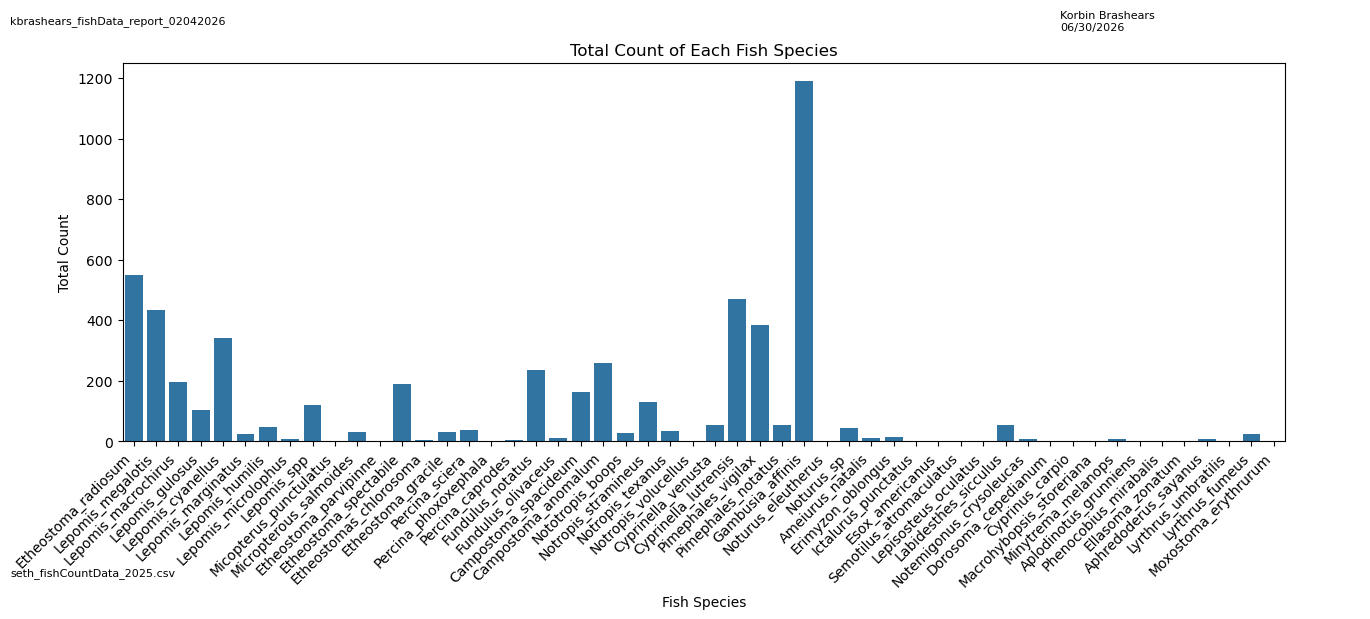

In [12]:
# ================================================== Data Analysis =========================================================

s_fcd_species_cols = s_fcd.columns[2:]                                  # selecting fish species columns for summing
fish_species_sum = s_fcd[s_fcd_species_cols].sum()                      # summing each fish species count

# ====================================================== Plotting ==========================================================

plt.figure(figsize=(15, 6))                                             # creating the figure for the bar plot with matplotlib
sns.barplot(x=fish_species_sum.index, y=fish_species_sum.values)        # creating the bar plot with seaborn
plt.xticks(rotation=45, ha='right')                                     # rotating x-axis labels for better readability and aligning them to the right
plt.xlabel('Fish Species')                                              # setting x-axis label
plt.ylabel('Total Count')                                               # setting y-axis label
plt.title('Total Count of Each Fish Species')                           # setting the title of the plot

label_plot_edges(
    program_names="kbrashears_fishData_report_02042026",                # calling the function to label the edges of the plot
    author_names="Korbin Brashears", 
    data_filenames="seth_fishCountData_2025.csv", 
    fig_filename="../figures/kbrashears_fishData_report_02042026/fish_species_barPlot.png",
    save = saveAll if saveAll else False                                # change False to True to save individual figure separately from saveAll
    )  

plt.show()                                                              # displaying the plot

### <a id='toc1_3_2_'></a>[Total Fish Genus Bar Plot](#toc0_)

>This cell preforms the same action as before on the **seth_genusCountData_2025.csv**, summing the columns and visualizing as a bar plot.

>Hopefully this can help to find outliers with unexpected differences between the population in an over all genus vs a species.

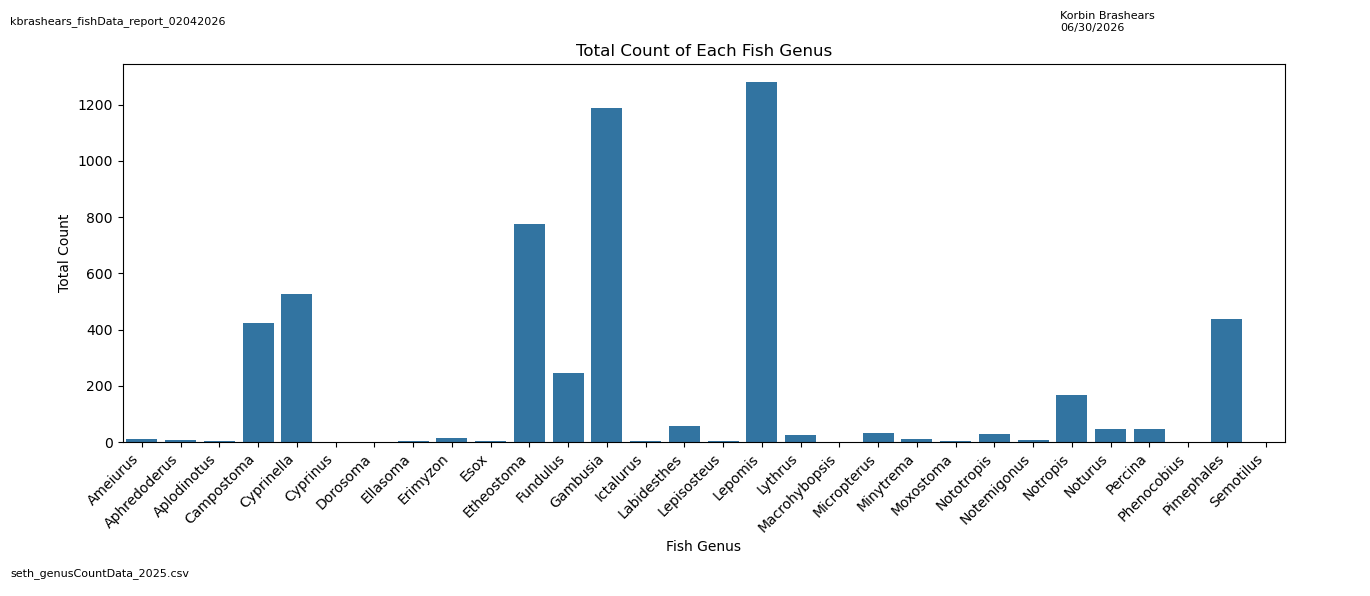

In [13]:
# ===================================================== Data Analysis =========================================================

s_gcd_genus_cols = s_gcd.columns[1:31]                                    # selecting fish genus columns for summing
fish_genus_sum = s_gcd[s_gcd_genus_cols].sum()                          # summing each fish genus count


# ====================================================== Plotting =============================================================

plt.figure(figsize=(15, 6))                                             # creating the figure for the bar plot with matplotlib
sns.barplot(x=fish_genus_sum.index, y=fish_genus_sum.values)            # creating the bar plot with seaborn
plt.xticks(rotation=45, ha='right')                                     # rotating x-axis labels for better readability and aligning them to the right
plt.xlabel('Fish Genus')                                                # setting x-axis label
plt.ylabel('Total Count')                                               # setting y-axis label
plt.title('Total Count of Each Fish Genus')                             # setting the title of the plot

label_plot_edges(
    program_names="kbrashears_fishData_report_02042026",                # calling the function to label the edges of the plot
    author_names="Korbin Brashears", 
    data_filenames="seth_genusCountData_2025.csv", 
    fig_filename="../figures/kbrashears_fishData_report_02042026/fish_genus_barPlot.png",
    save = saveAll if saveAll else False                                # change False to True to save individual figure separately from saveAll
    )  

plt.show()                                                              # displaying the plot

### <a id='toc1_3_3_'></a>[Total Population and Genus at Each Site](#toc0_)

> 

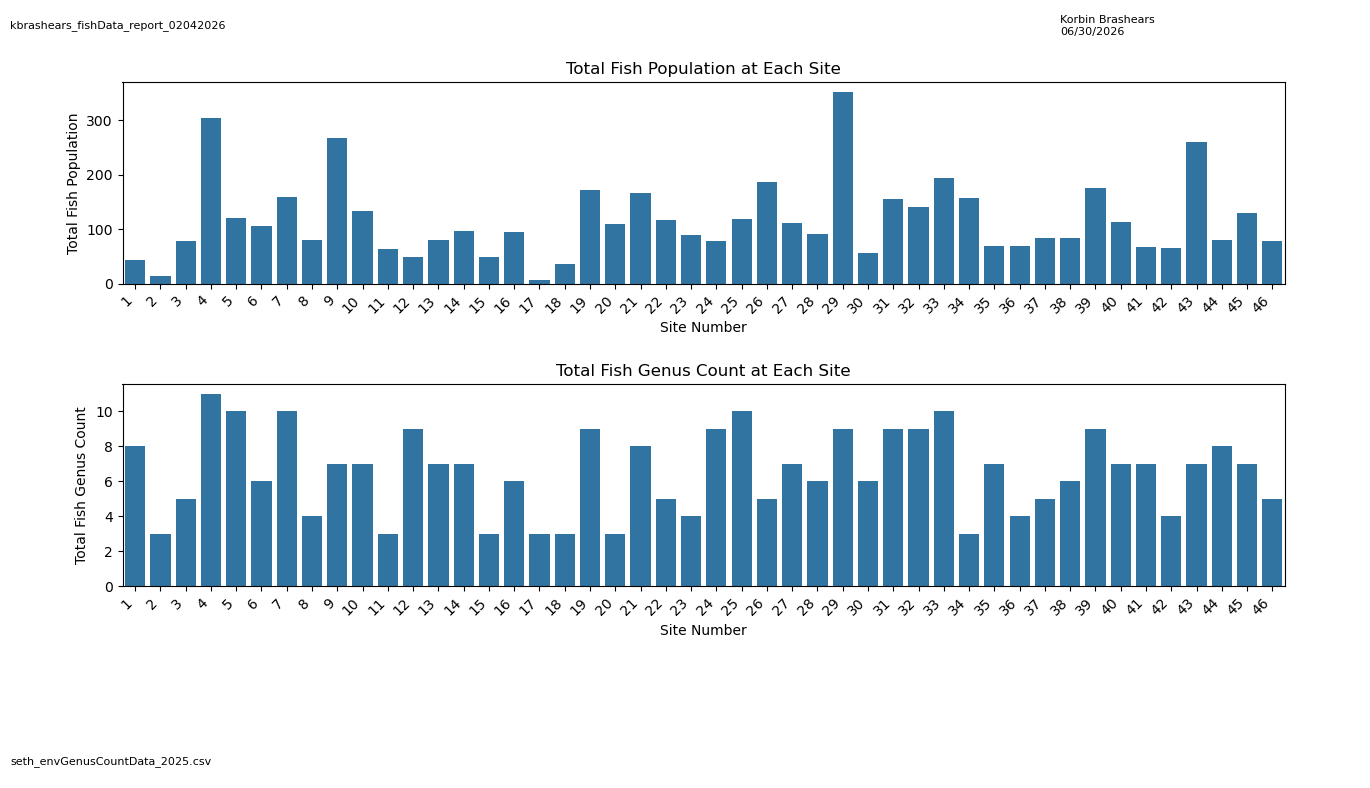

In [14]:
# ====================================================== Plotting =========================================================

plt.figure(figsize=(15, 8))                                             # creating the figure for the bar plot with matplotlib


plt.subplot(211)
sns.barplot(x=s_egcd['SiteN'], y=s_egcd['t_population'])                # creating the bar plot with seaborn
plt.xticks(rotation=45, ha='right')                                     # rotating x-axis labels for better readability and aligning them to the right
plt.xlabel('Site Number')                                               # setting x-axis label
plt.ylabel('Total Fish Population')                                     # setting y-axis label
plt.title('Total Fish Population at Each Site')                         # setting the title of the plot

plt.subplot(212)
sns.barplot(x=s_egcd['SiteN'], y=s_egcd['t_genus'])                     # creating the bar plot with seaborn
plt.xticks(rotation=45, ha='right')                                     # rotating x-axis labels for better readability and aligning them to the right
plt.xlabel('Site Number')                                               # setting x-axis label
plt.ylabel('Total Fish Genus Count')                                    # setting y-axis label
plt.title('Total Fish Genus Count at Each Site')                        # setting the title of the plot

plt.subplots_adjust(hspace=0.5)                                         # adjusting the space between subplots

label_plot_edges(
    program_names="kbrashears_fishData_report_02042026",                # calling the function to label the edges of the plot
    author_names="Korbin Brashears", 
    data_filenames="seth_envGenusCountData_2025.csv", 
    fig_filename="../figures/kbrashears_fishData_report_02042026/fish_population_barPlot.png",
    save = saveAll if saveAll else False                                # change False to True to save individual figure separately from saveAll
    )

plt.show()                                                              # displaying the plot


### <a id='toc1_3_4_'></a>[Total Population and Genus at Each Site Ordered Bar Plot](#toc0_)

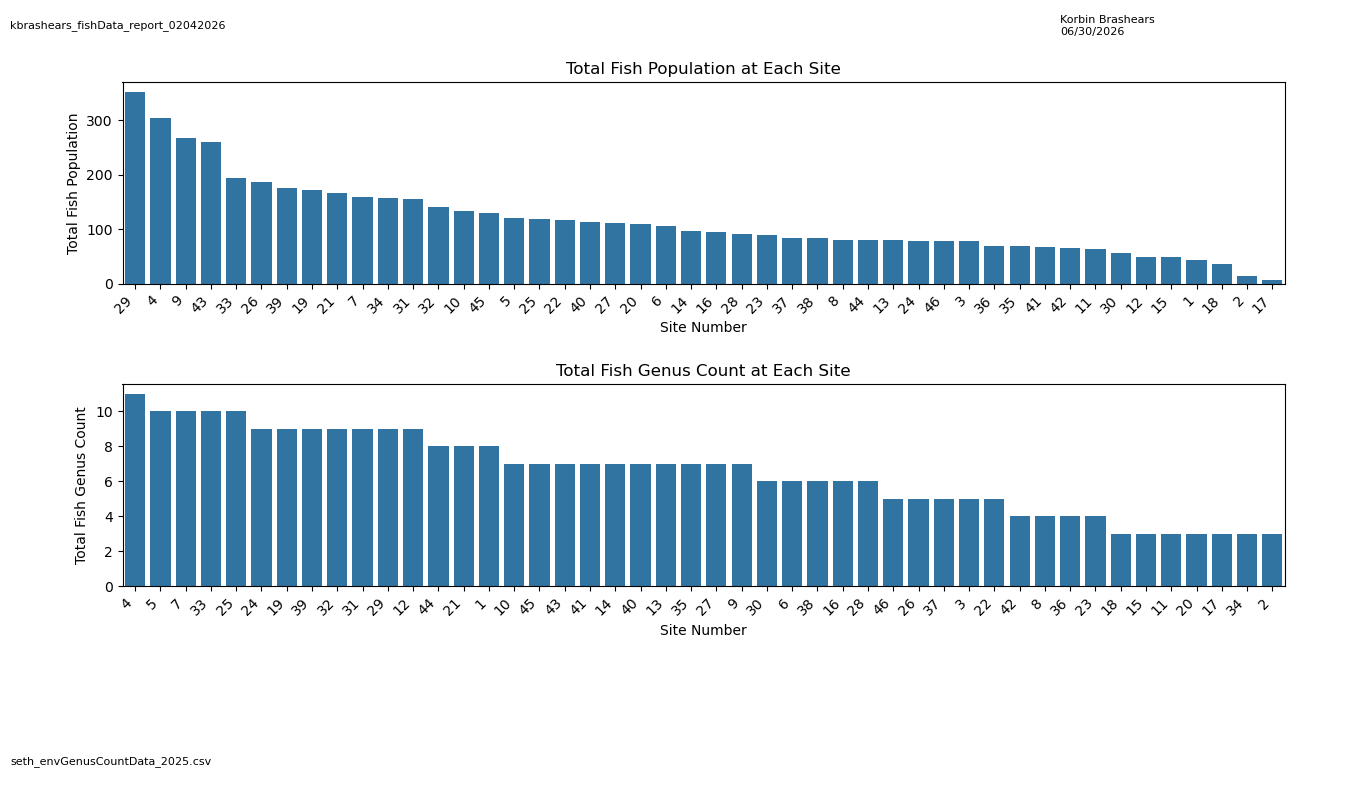

In [15]:
# ===================================================== Data Analysis =========================================================

s_egcd_tps = s_egcd.sort_values(by='t_population', ascending=False)     # sorting the data frame by total fish population in descending order
s_egcd_tgs = s_egcd.sort_values(by='t_genus', ascending=False)          # sorting the data frame by total fish genus count in descending order


# ====================================================== Plotting =============================================================

plt.figure(figsize=(15, 8))                                             # creating the figure for the bar plot with matplotlib

plt.subplot(211)
sns.barplot(x=s_egcd_tps['SiteN'], y=s_egcd_tps['t_population'], order=s_egcd_tps['SiteN'].unique())        # creating the bar plot with seaborn
plt.xticks(rotation=45, ha='right')                                     # rotating x-axis labels for better readability and aligning them to the right
plt.xlabel('Site Number')                                               # setting x-axis label
plt.ylabel('Total Fish Population')                                     # setting y-axis label
plt.title('Total Fish Population at Each Site')                         # setting the title of the plot

plt.subplot(212)
sns.barplot(x=s_egcd_tgs['SiteN'], y=s_egcd_tgs['t_genus'], order=s_egcd_tgs['SiteN'].unique())             # creating the bar plot with seaborn
plt.xticks(rotation=45, ha='right')                                     # rotating x-axis labels for better readability and aligning them to the right
plt.xlabel('Site Number')                                               # setting x-axis label
plt.ylabel('Total Fish Genus Count')                                    # setting y-axis label
plt.title('Total Fish Genus Count at Each Site')                        # setting the title of the plot

plt.subplots_adjust(hspace=0.5)                                         # adjusting the space between subplots

label_plot_edges(
    program_names="kbrashears_fishData_report_02042026",                # calling the function to label the edges of the plot
    author_names="Korbin Brashears", 
    data_filenames="seth_envGenusCountData_2025.csv", 
    fig_filename="../figures/kbrashears_fishData_report_02042026/fish_population_barPlot.png",
    save = saveAll if saveAll else False                                # change False to True to save individual figure separately from saveAll
    )

plt.show()                                                              # displaying the plot


### <a id='toc1_3_5_'></a>[Site Attribute Bar Plots](#toc0_)

> A function for selecting and summing the attribute columns from the file **seth_envData_2025.csv** for a given site N. This will help to see the over all site attribute distribution at a site of interest and manually spot similarities or outliers.

In [16]:
# ====================================================== Defining Function =========================================================

def site_attributes_bar_plotter(siteN, save=False):
    
    
    # ===================================================== Data Analysis =========================================================
    
    # Row Selection
    site_att_v = s_ed[siteN-1:siteN]                                                # selecting the row corresponding to the specified site number

    att_cols = site_att_v.columns[4:]                                               # getting the columns corresponding to environmental attributes
    site_att_v = site_att_v[att_cols]                                               # selecting only the attribute columns
    
    # Normalization
    max_val = site_att_v.values.max()                                               # finding the maximum attribute value for normalization
    site_att_v = site_att_v / max_val                                               # normalizing the attribute values by dividing by the maximum value

    
    # Sorting
    site_att_ov = site_att_v.T.sort_values(by=siteN-1, ascending=False).T           # transposing, sorting by the attribute values in descending order, and transposing back to original format 
    
    
    # ===================================================== Plotting =========================================================
    
    plt.figure(figsize=(10, 10))                                                    # creating the figure for the bar plot with matplotlib  
    
    
    #----------------------------------------------------------------
    # Subplot 1: Unordered Bar Plot
    #----------------------------------------------------------------
    
    # Creating Subplot
    plt.subplot(211)                                                                # creating the first subplot for the unordered bar plot
    
    # Creating Bar Plot
    sns.barplot(x=site_att_v.columns, y=site_att_v.values[0])                       # creating the bar plot with seaborn using column names as x-axis labels and attribute values as y-axis values
    
    # Setting Lables and Rotation
    plt.xticks(rotation=45, ha='right')                                             # rotating x-axis labels for better readability and aligning them to the right
    plt.xlabel('')                                                                  # setting x-axis label
    plt.ylabel('Attribute Value')                                                   # setting y-axis label
    
    # Setting Title
    plt.title(f'Environmental Attributes for Site #{siteN}')                        # setting the title of the plot with the site number    
    
    
    #----------------------------------------------------------------
    # Subplot 2: Ordered Bar Plot
    #----------------------------------------------------------------
    
    # Creating Subplot
    plt.subplot(212)                                                                # creating the second subplot for the ordered bar plot  
    
    # Creating Bar Plot
    sns.barplot(x=site_att_ov.columns, y=site_att_ov.values[0])                     # creating the ordered bar plot with seaborn using column names as x-axis labels and attribute values as y-axis values
    
    # Setting Lables and Rotation
    plt.xticks(rotation=45, ha='right')                                             # rotating x-axis labels for better readability and aligning them to the right
    plt.xlabel('Environmental Attributes')                                          # setting x-axis label
    plt.ylabel('Attribute Value')                                                   # setting y-axis label
        
    # Setting Title
    plt.title(f'Ordered Environmental Attributes for Site #{siteN}')                # setting the title of the plot with the site number
        
    
    # Adding Vertical Space Between Subplots
    plt.subplots_adjust(hspace=0.75)                                                # adjusting the space between subplots
    
    
    # ============================================= Adding Plot Edge Labels =================================================
    
    label_plot_edges(
        program_names="kbrashears_fishData_report_02042026",                        # calling the function to label the edges of the plot
        author_names="Korbin Brashears", 
        data_filenames="seth_envData_2025.csv", 
        fig_filename=f"../figures/kbrashears_fishData_report_02042026/site_{siteN}_attributes_barPlot.png",
        save = saveAll if saveAll else save
    )
    
    plt.show()
    
    return None
    

#### <a id='toc1_3_5_1_'></a>[High t_population Sites](#toc0_)

> Attribute bar plots for the top 4 t_population sites in order (high to low t_pop)

##### <a id='toc1_3_5_1_1_'></a>[Site #29 Bar Plots](#toc0_)

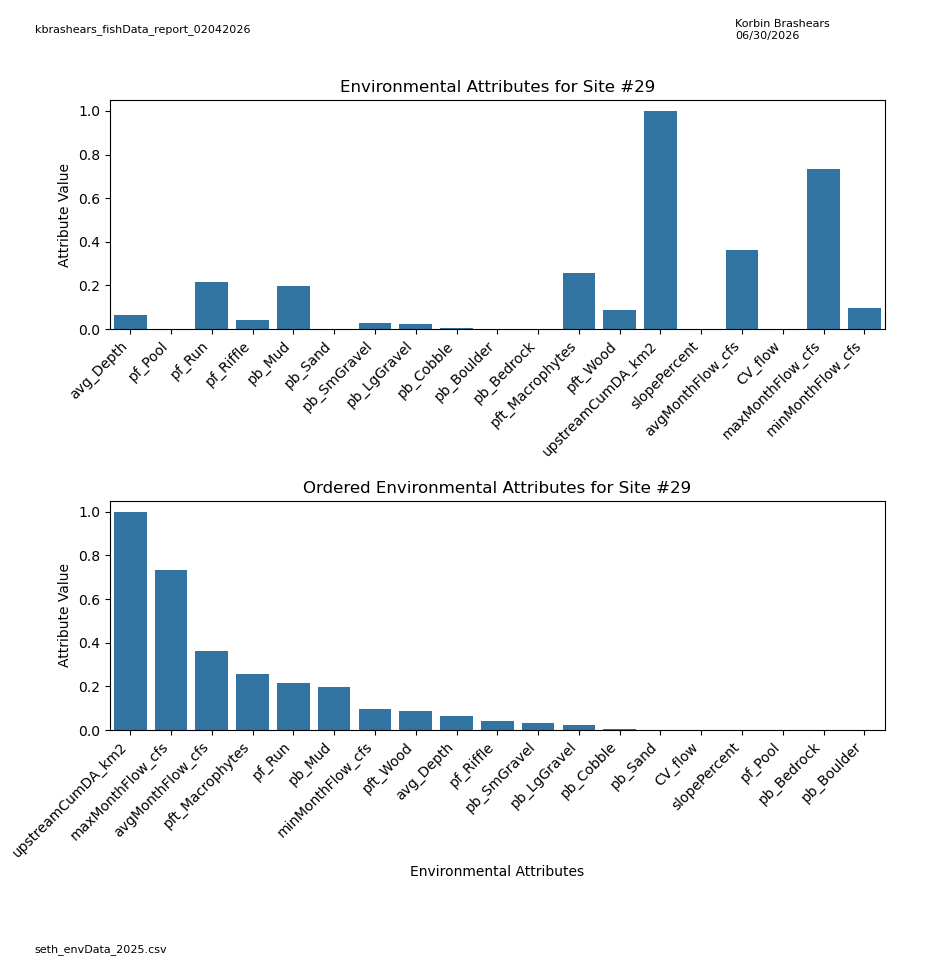

In [17]:
site_attributes_bar_plotter(siteN=29, save=False)       # calling the function to create bar plots of environmental attributes

##### <a id='toc1_3_5_1_2_'></a>[Site #4 Bar Plots](#toc0_)

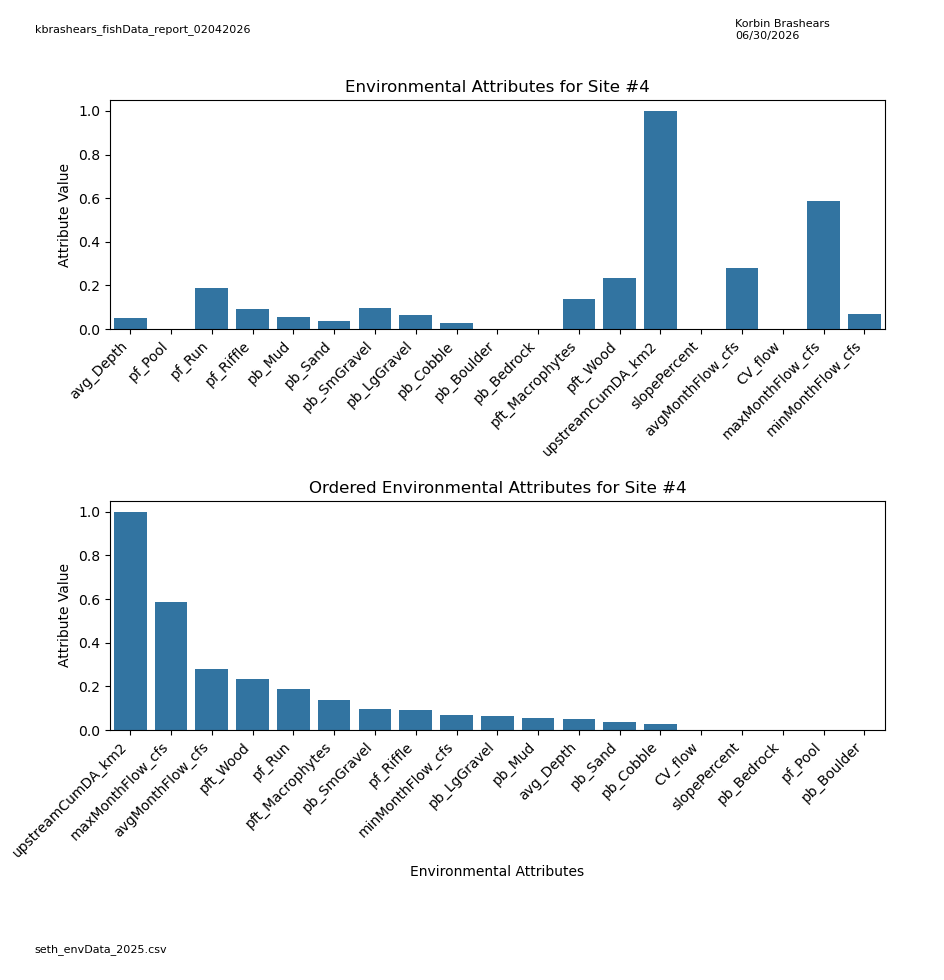

In [18]:
site_attributes_bar_plotter(siteN=4, save=False)       # calling the function to create bar plots of environmental attributes

##### <a id='toc1_3_5_1_3_'></a>[Site #9 Bar Plots](#toc0_)

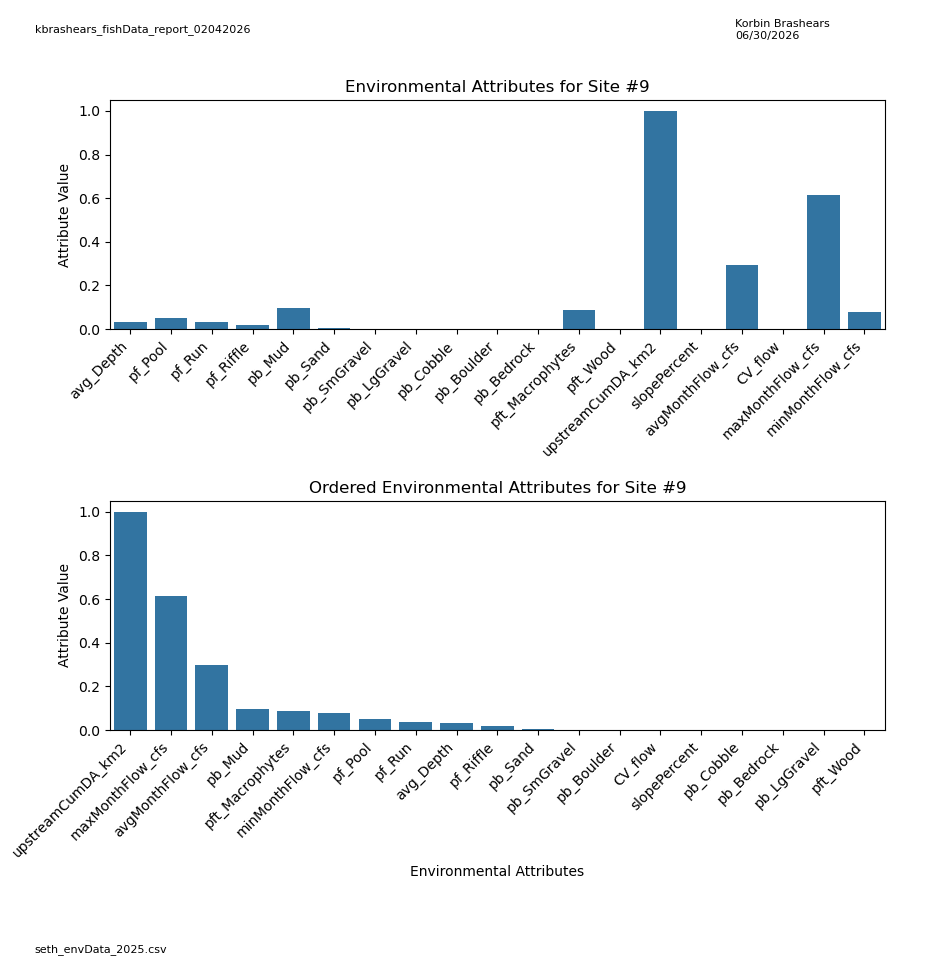

In [19]:
site_attributes_bar_plotter(siteN=9, save=False)       # calling the function to create bar plots of environmental attributes

##### <a id='toc1_3_5_1_4_'></a>[Site #43 Bar Plots](#toc0_)

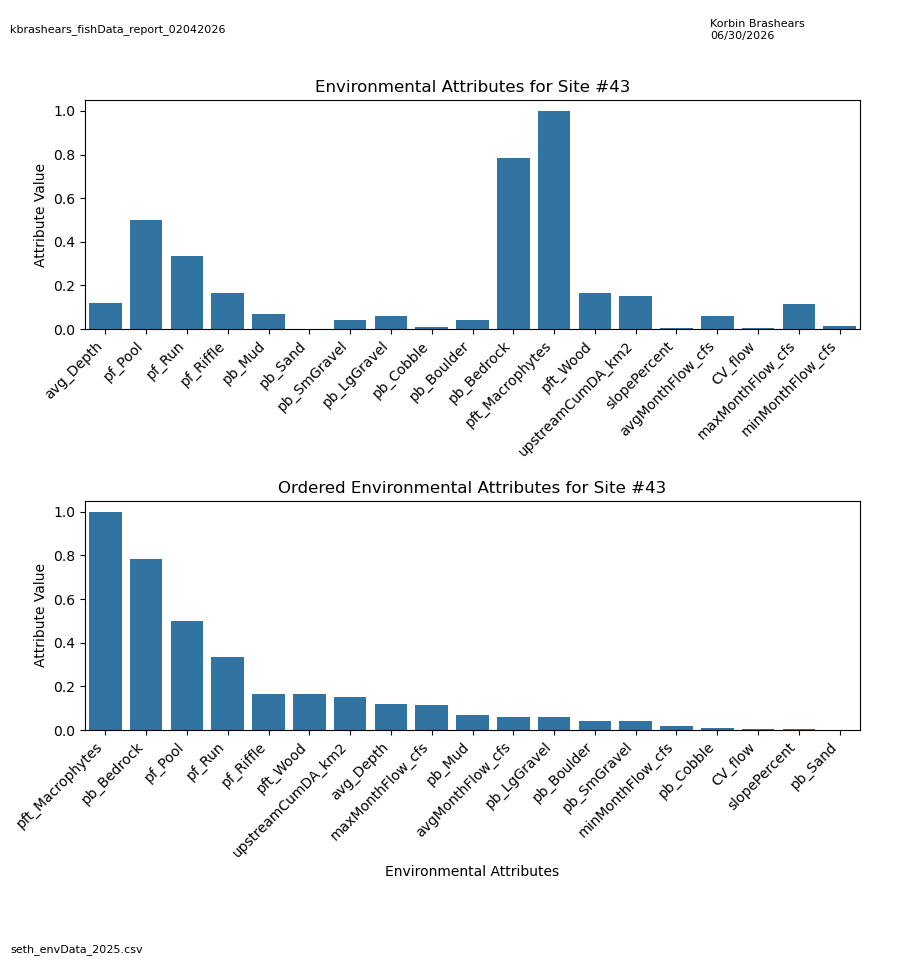

In [20]:
site_attributes_bar_plotter(siteN=43, save=False)       # calling the function to create bar plots of environmental attributes

#### <a id='toc1_3_5_2_'></a>[Low t_population Sites](#toc0_)

> Attribute bar plots for the bottom 4 t_population sites in order (high to low t_pop)

##### <a id='toc1_3_5_2_1_'></a>[Site #1 Bar Plots](#toc0_)

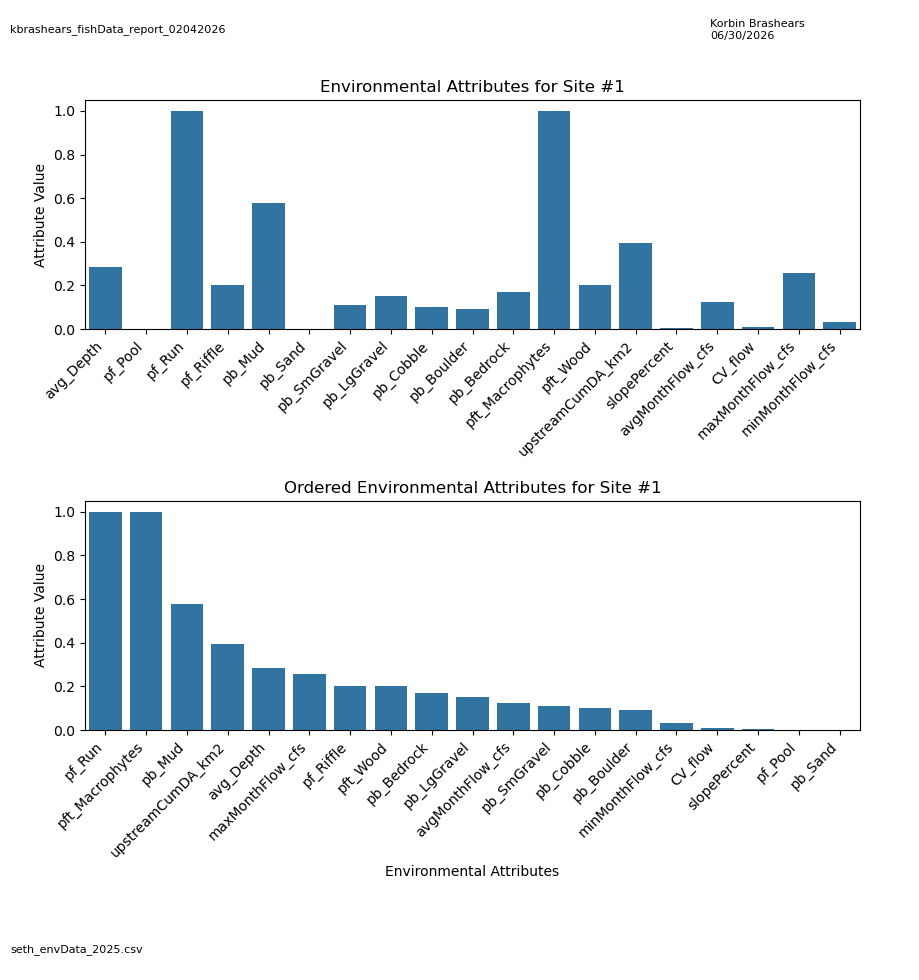

In [21]:
site_attributes_bar_plotter(siteN=1, save=False)       # calling the function to create bar plots of environmental attributes

##### <a id='toc1_3_5_2_2_'></a>[Site #18 Bar Plots](#toc0_)

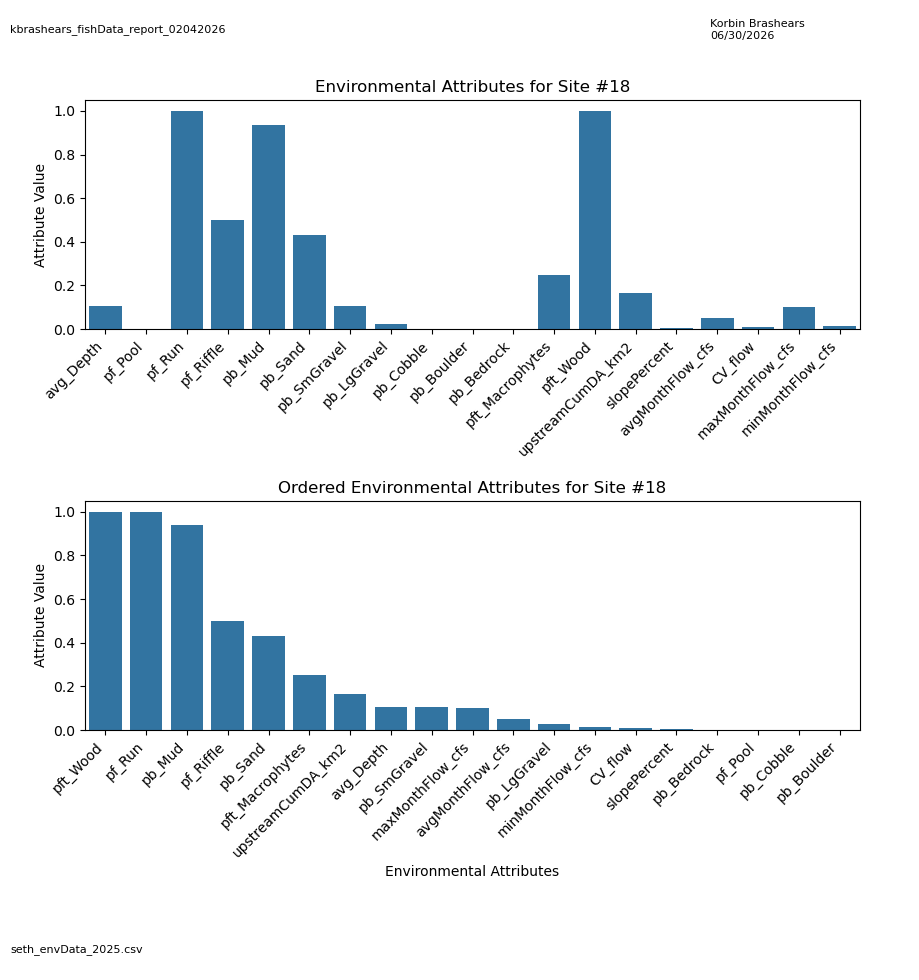

In [22]:
site_attributes_bar_plotter(siteN=18, save=False)       # calling the function to create bar plots of environmental attributes

##### <a id='toc1_3_5_2_3_'></a>[Site #2 Bar Plots](#toc0_)

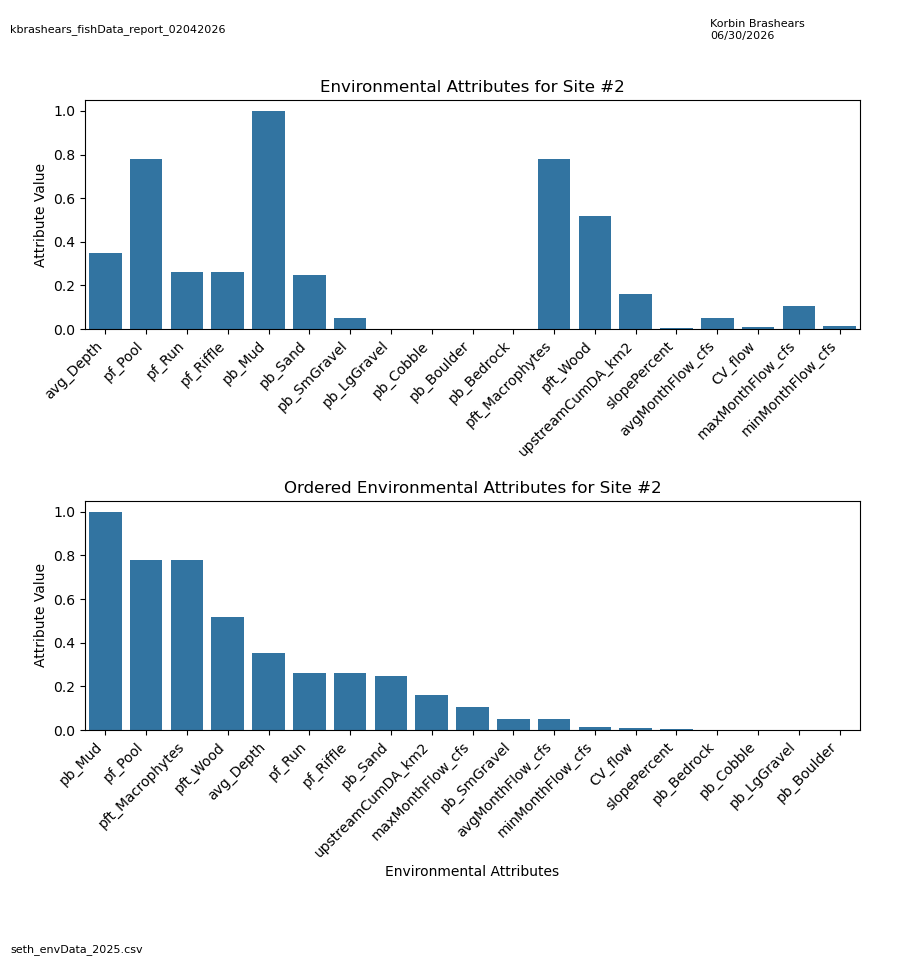

In [23]:
site_attributes_bar_plotter(siteN=2, save=False)       # calling the function to create bar plots of environmental attributes

##### <a id='toc1_3_5_2_4_'></a>[Site #17 Bar Plots](#toc0_)

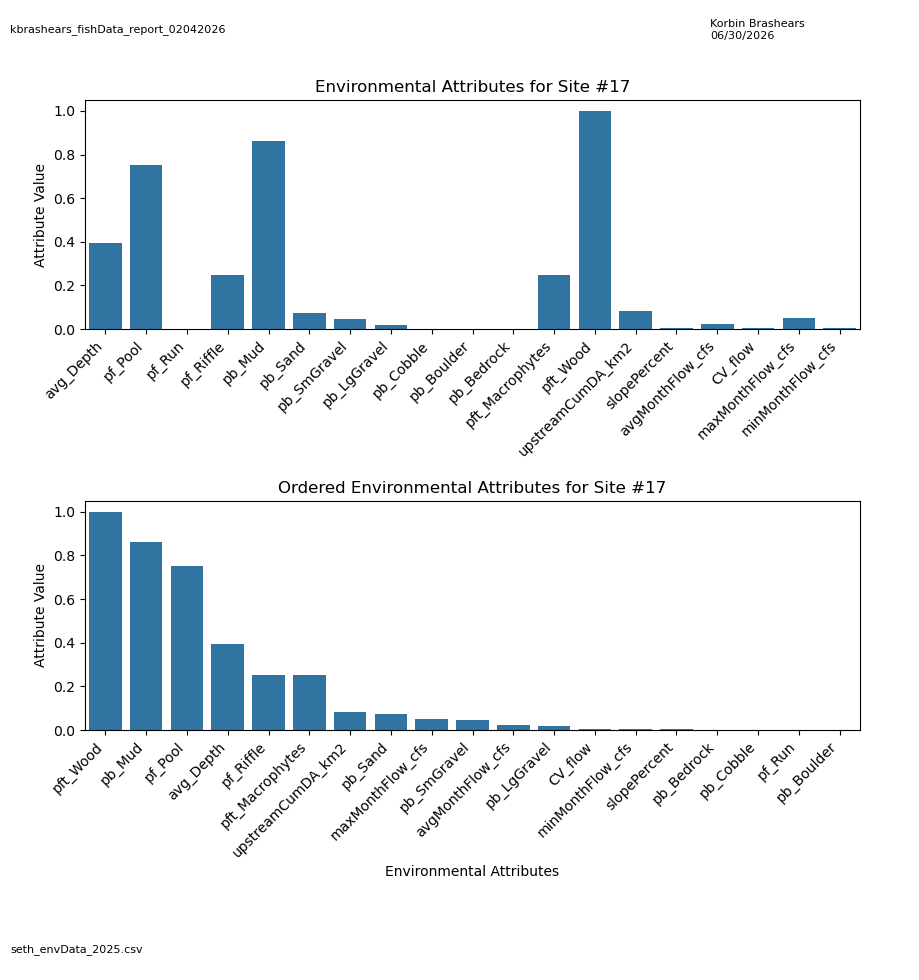

In [24]:
site_attributes_bar_plotter(siteN=17, save=False)       # calling the function to create bar plots of environmental attributes

## <a id='toc1_4_'></a>[Correlation Plots](#toc0_)

### <a id='toc1_4_1_'></a>[Correlation Heatmap](#toc0_)

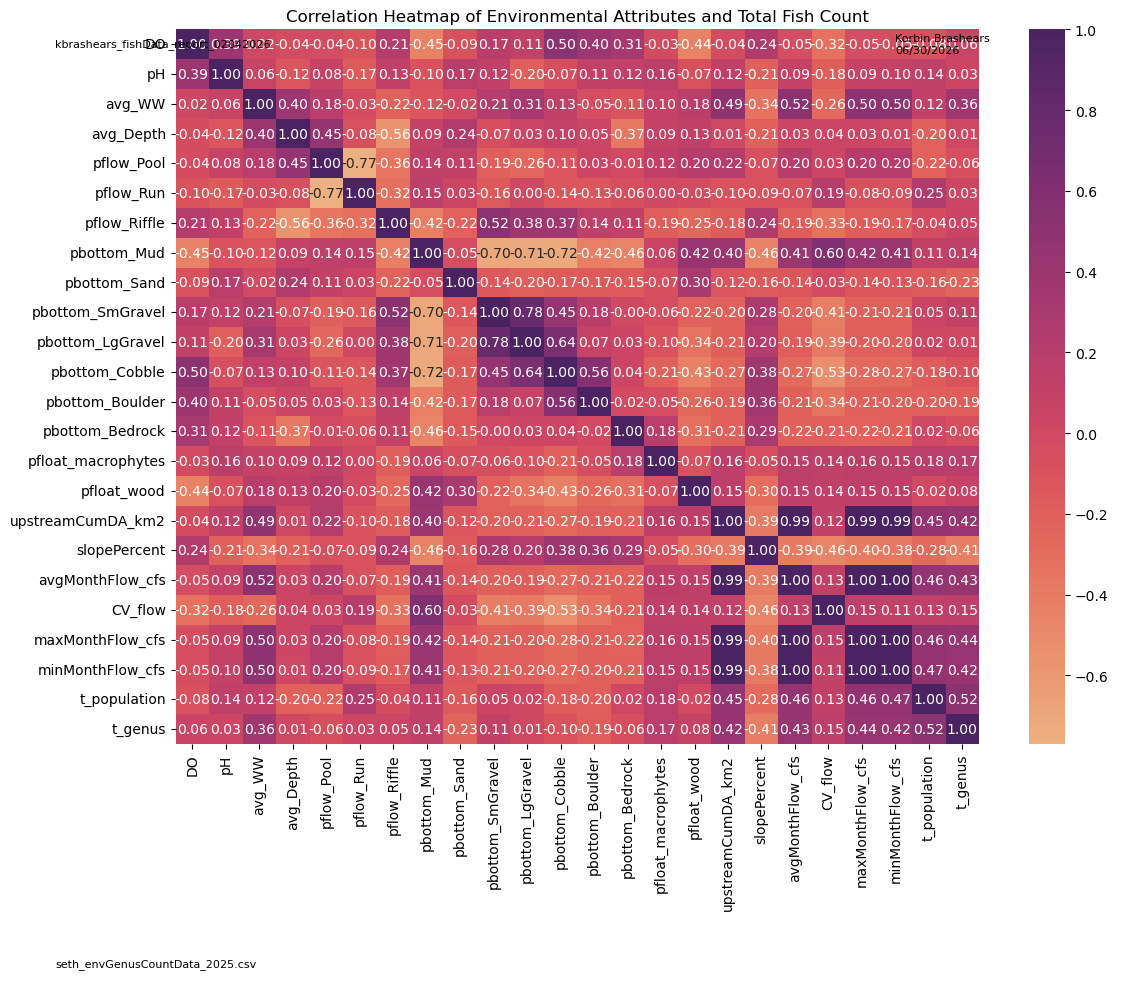

In [25]:
# ===================================================== Data Analysis ===========================================================

# Selecting Attribute Columns and Fish Count Columns
att_cols = list(s_egcd.columns[4:26]) + list(s_egcd.columns[56:])                            # selecting the columns corresponding to environmental attributes

# Calculating Correlation Matrix
s_ed_c_m = s_egcd[att_cols].corr(numeric_only=True)                                          # calculating the correlation matrix for the environmental attributes

# ===================================================== Plotting =================================================================

# Creating Figure
plt.figure(figsize=(12, 10))                                                                 # creating the figure for the heatmap with matplotlib

# Creating Heatmap
sns.heatmap(s_ed_c_m, annot=True, cmap='flare', fmt='.2f')                                   # creating the heatmap with seaborn using the correlation matrix, annotating the values, and using the 'coolwarm' color map

plt.title('Correlation Heatmap of Environmental Attributes and Total Fish Count')            # setting the title of the plot

plt.tight_layout()                                                                           # adjusting the layout to prevent overlap

label_plot_edges(
    program_names="kbrashears_fishData_report_02042026",                                     # calling the function to label the edges of the plot
    author_names="Korbin Brashears", 
    data_filenames="seth_envGenusCountData_2025.csv", 
    fig_filename="../figures/kbrashears_fishData_report_02042026/environmental_attributes_correlation_heatmap.png",
    save = saveAll if saveAll else False                                                     # change False to True to save individual figure separately from saveAll
    )

plt.show()

### <a id='toc1_4_2_'></a>[Ranked Correlation Decay Plot](#toc0_)

> Creating a function to take a target feature to compare against, and the features to be ranked, finds the correlations, sorts them high to low, and plots the result.

In [60]:
# ====================================================== Defining Function =========================================================

def corr_decay_plotter(attribute, features, save=False):
    
    # ===================================================== Data Analysis =========================================================
    
    # Calculating Correlations with Respect to the Specified Attribute
    cd_raw = features.corrwith(attribute, numeric_only=True)                           # calculating the correlation of the specified attribute with the specified features (signed)
    neg_idx = cd_raw < 0                                                               # saving the indices of correlations that are less than zero
    cd = cd_raw.abs()                                                                  # taking the absolute value for plotting
    
    # Sorting Correlation Values
    cd_sorted = cd.sort_values(ascending=False)                                        # sorting the correlation values in descending order
    neg_sorted = neg_idx.loc[cd_sorted.index]                                          # reordering the negative-index mask to match the sorted values
    
    
    # ===================================================== Plotting =========================================================
    
    # Creating the Figure
    plt.figure(figsize=(12, 6))                                                        # creating the figure for the bar plot with matplotlib
    
    # Creating Line Plot (base line)
    sns.lineplot(x=cd_sorted.index, y=cd_sorted.values, color='blue', zorder=1)                  # creating a line plot with seaborn using the sorted correlation values
    
    # Plotting Positive Correlations
    sns.scatterplot(
        x=cd_sorted.index[~neg_sorted],
        y=cd_sorted.values[~neg_sorted],
        color="blue",
        zorder=2,
        s=40
    )                                                                                   # plotting positive correlations in blue
    
    # Plotting Negative Correlations
    sns.scatterplot(
        x=cd_sorted.index[neg_sorted],
        y=cd_sorted.values[neg_sorted],
        color="orange",
        zorder=2,
        s=40
    )                                                                                   # plotting negative correlations in orange
    
    # Setting Labels and Rotation
    plt.xticks(rotation=45, ha='right')                                                # rotating x-axis labels for readability
    plt.xlabel('')                                                                      # setting x-axis label as the specified attribute
    plt.ylabel('Correlation Coefficient')                                               # setting y-axis label
    plt.title(f'Correlation Decay of features with {attribute.name}')                   # setting the title of the plot with the specified attribute
    
    plt.grid(True)                                                                      # adding a grid to the plot for better readability
       
    # ============================================= Adding Plot Edge Labels ======================================================
       
    # Labeling Plot Edges  
    label_plot_edges(
        program_names="kbrashears_fishData_report_02042026",                           # calling the function to label the edges of the plot
        author_names="Korbin Brashears", 
        data_filenames="seth_envGenusCountData_2025.csv", 
        fig_filename=f"../figures/kbrashears_fishData_report_02042026/]{attribute.name}_correlation_decay_plot.png",
        save = saveAll if saveAll else save                                            # applying global save override
    )
    
    plt.show()              
    
    return None                                                            

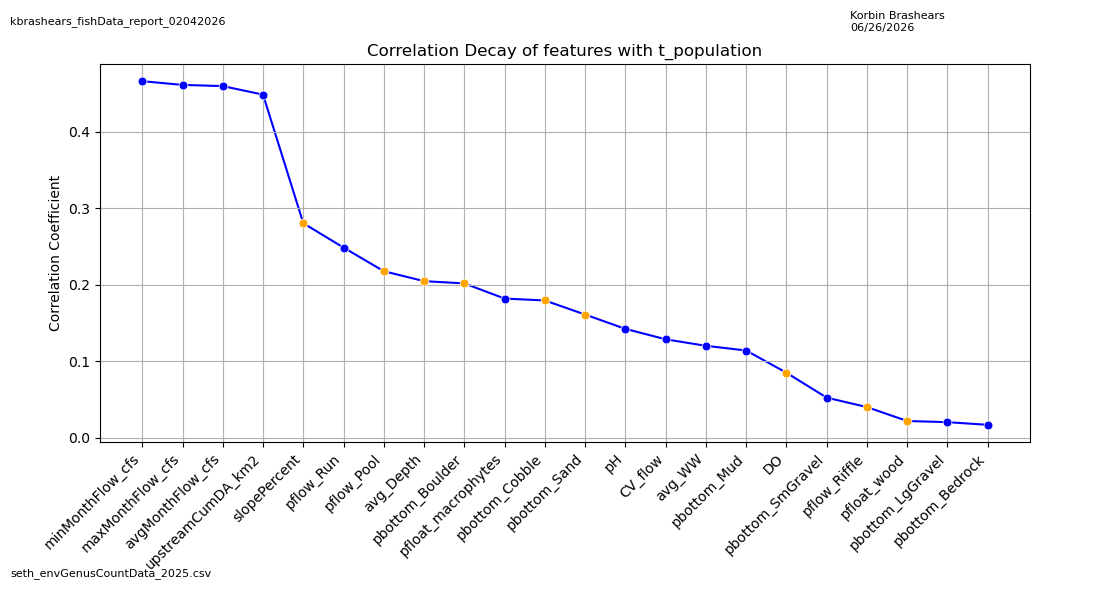

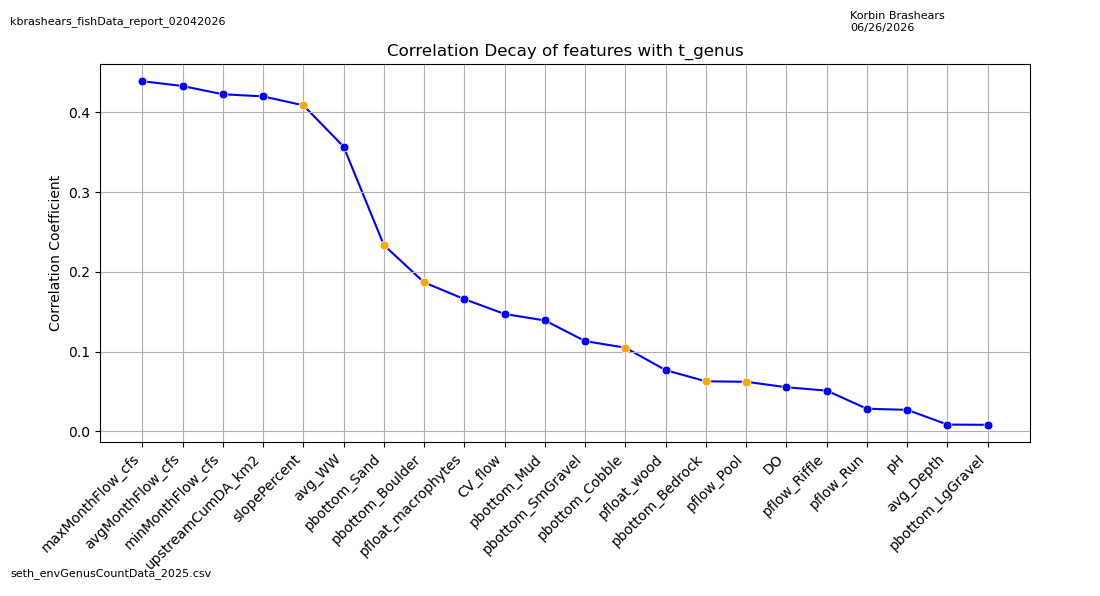

In [61]:
att_cols = s_egcd.columns[4:26]                                                                  # selecting the columns corresponding to environmental attributes

corr_decay_plotter(attribute=s_egcd['t_population'], features=s_egcd[att_cols], save=False)      # calling the function to create a correlation decay plot for total fish population with environmental attributes

corr_decay_plotter(attribute=s_egcd['t_genus'], features=s_egcd[att_cols], save=False)           # calling the function to create a correlation decay plot for total fish genus with environmental attributes


### <a id='toc1_4_3_'></a>[Scatter TrendLine Plotter](#toc0_)

> Defining a function, **scatter_trendLine_plotter()** to plot a scatter plot and trend line for x and y vectors of the same length.

In [62]:
# ====================================================== Defining Function =========================================================

def scatter_trendLine_plotter(x, y, pointLabels=True, save=False):
    
    # ===================================================== Plotting ===============================================================
    
    plt.figure(figsize=(10, 6))                                                                       # creating the figure for the scatter plot with matplotlib
    
    # Adding Trend Line
    sns.regplot(
        x=x,
        y=y,
        scatter=False,        # turn off regplot’s own dots
        line_kws={"linewidth": 2, "linestyle": "--", "zorder": 1, "color": "#000000"}
    )
    
    # Creating Scatter Plot
    sns.scatterplot(
        x=x,
        y=y,
        s=60,                 # dot size
        color="#ff0000",      # custom hex color (red)
        #zorder=2,
        edgecolor="black"     # optional: outline around dots
    )
    
    # Adding Point Index Labels (if enabled)
    if pointLabels:
        for i in range(len(x)):
            plt.text(x[i], y[i], str(i), fontsize=9, ha='right', va='bottom', color='#000099', zorder=3)       # adding index labels to each point
    
    # Labeling Axis and Title
    plt.xlabel(x.name)                                                                             # setting x-axis label as the specified attribute
    plt.ylabel(y.name)                                                                          # setting y-axis label
    
    plt.title(f'{y.name} vs {x.name}')                                                # setting the title of the plot with the specified attribute

    # ============================================= Adding Plot Edge Labels ======================================================
    
    # Adding Plot Edge Labels
    label_plot_edges(
        program_names="kbrashears_fishData_report_02042026",                                          # calling the function to label the edges of the plot
        author_names="Korbin Brashears", 
        data_filenames="seth_envData_2025.csv", 
        fig_filename=f"../figures/kbrashears_fishData_report_02042026/{x.name}_vs_{y.name}_trendLine.png",
        save = saveAll if saveAll else False                                
    )
    
    plt.show()                                                                             
    
    return None

#### <a id='toc1_4_3_1_'></a>[pH Scatter Plot](#toc0_)

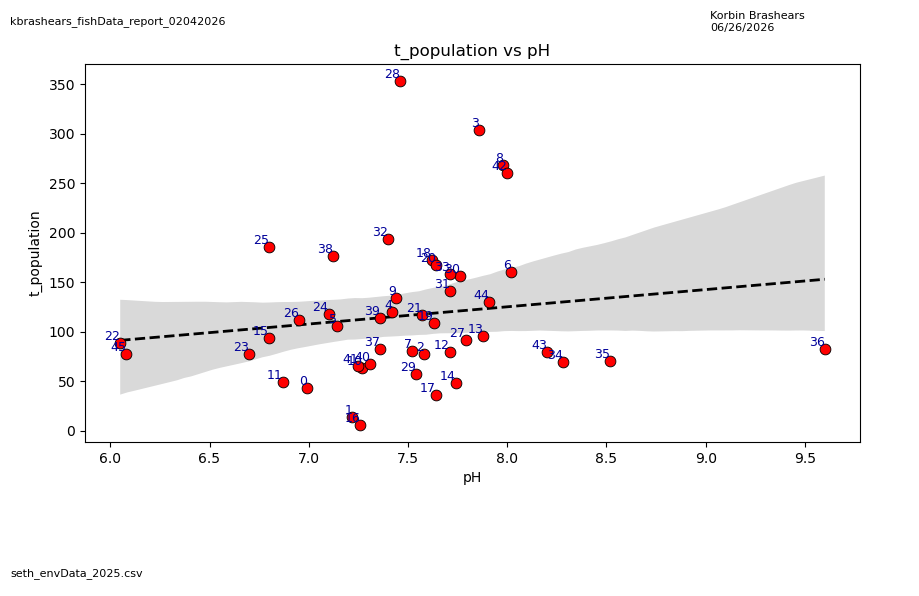

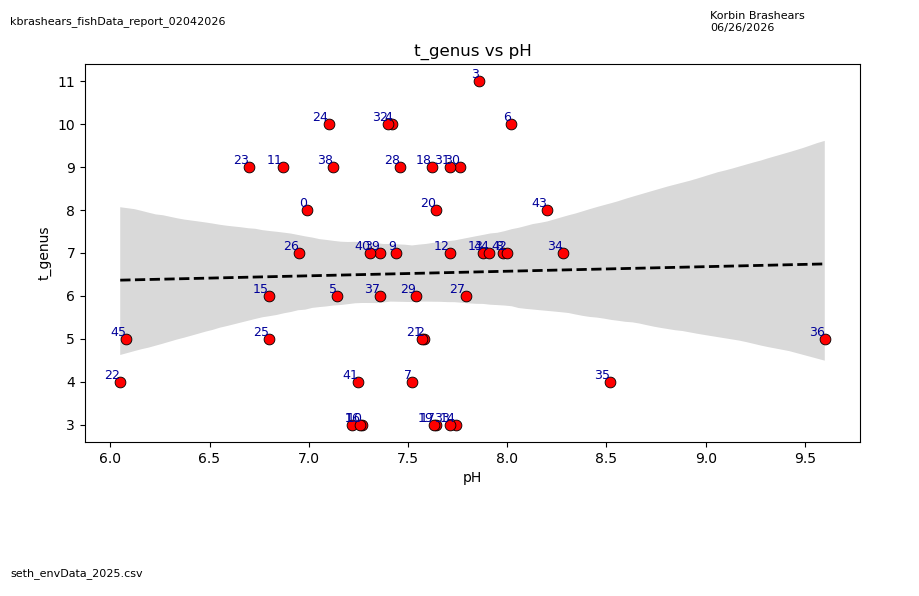

In [63]:
scatter_trendLine_plotter(s_ed['pH'], s_egcd['t_population'], save=False)       # calling the function to create scatter plots of pH

scatter_trendLine_plotter(s_ed['pH'], s_egcd['t_genus'], save=False)            # calling the function to create scatter plots of pH

#### <a id='toc1_4_3_2_'></a>[upstreamCumDA_km2 Scatter Plot](#toc0_)

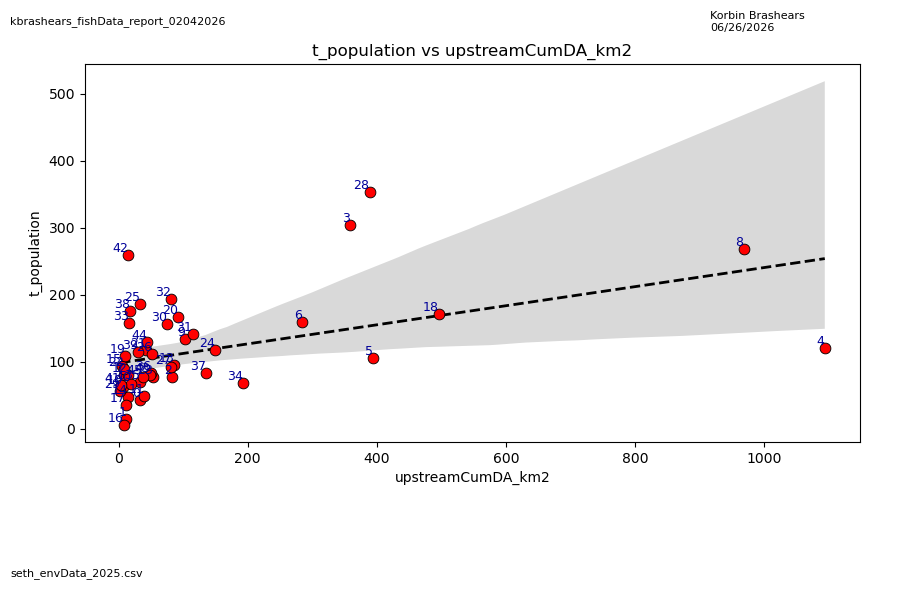

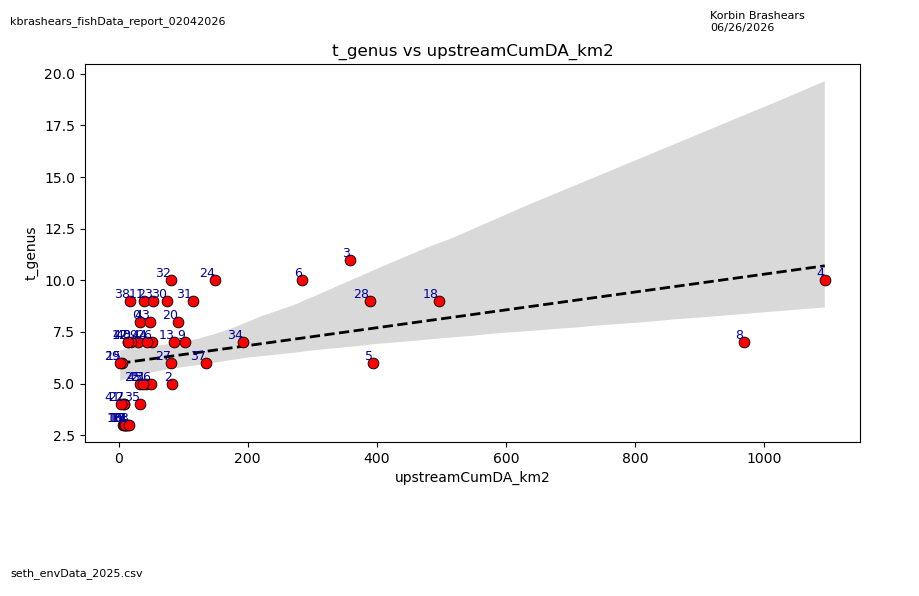

In [64]:
scatter_trendLine_plotter(s_ed['upstreamCumDA_km2'], s_egcd['t_population'], save=False)         # calling the function to create scatter plots of pH

scatter_trendLine_plotter(s_ed['upstreamCumDA_km2'], s_egcd['t_genus'], save=False)            # calling the function to create scatter plots of pH

#### <a id='toc1_4_3_3_'></a>[pb_Bedrock Scatter Plot](#toc0_)

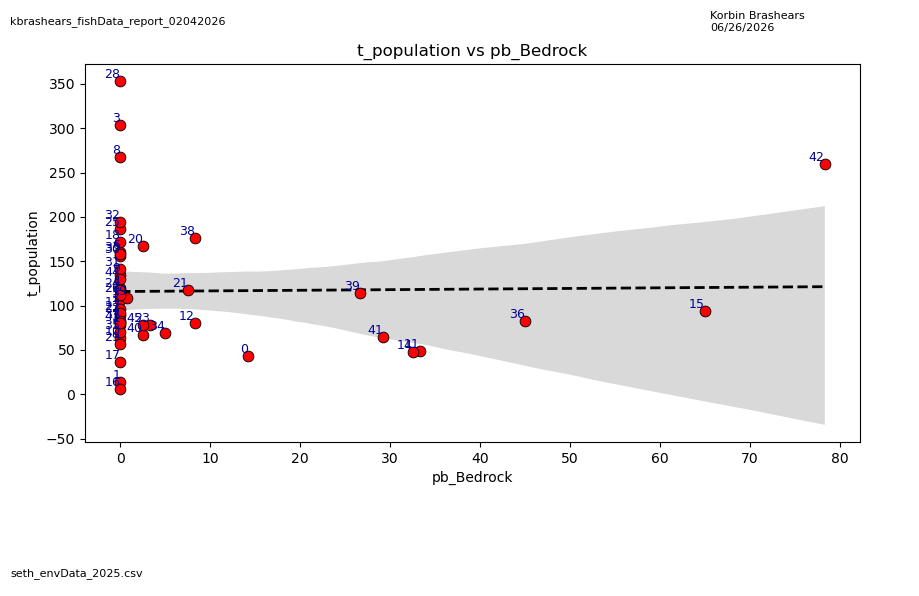

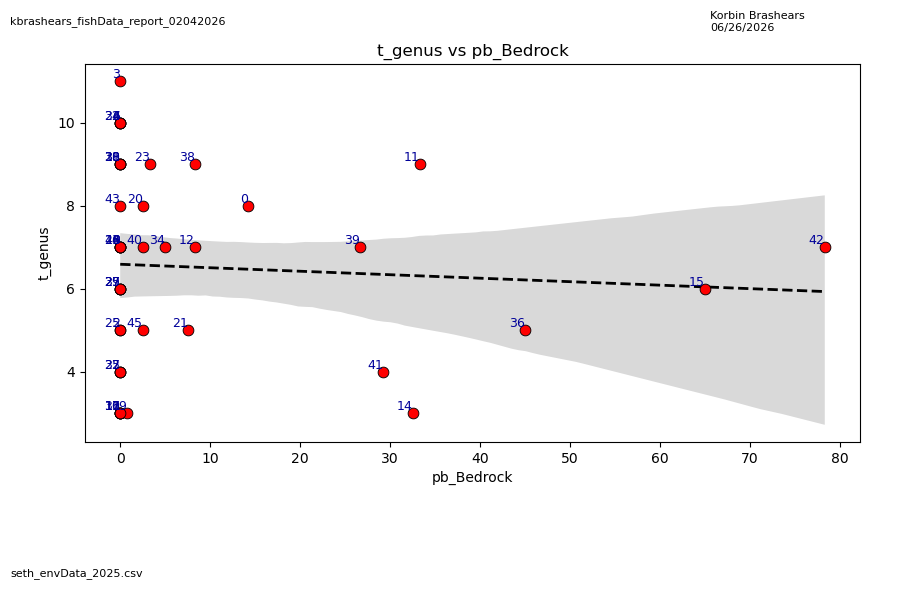

In [65]:
scatter_trendLine_plotter(s_ed['pb_Bedrock'], s_egcd['t_population'], save=False)         # calling the function to create scatter plots of pH

scatter_trendLine_plotter(s_ed['pb_Bedrock'], s_egcd['t_genus'], save=False)              # calling the function to create scatter plots of pH

#### <a id='toc1_4_3_4_'></a>[pft_macrophytes  Scatter Plot](#toc0_)

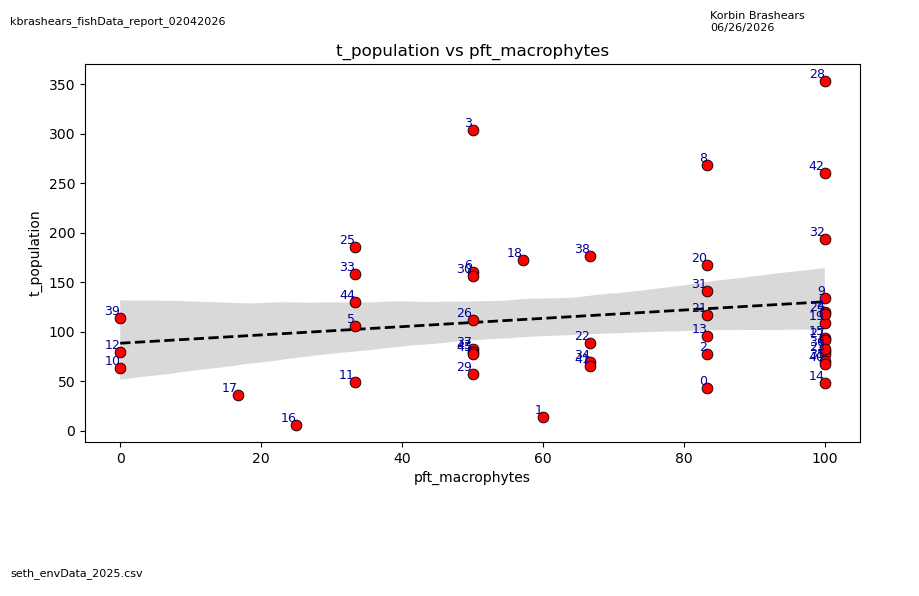

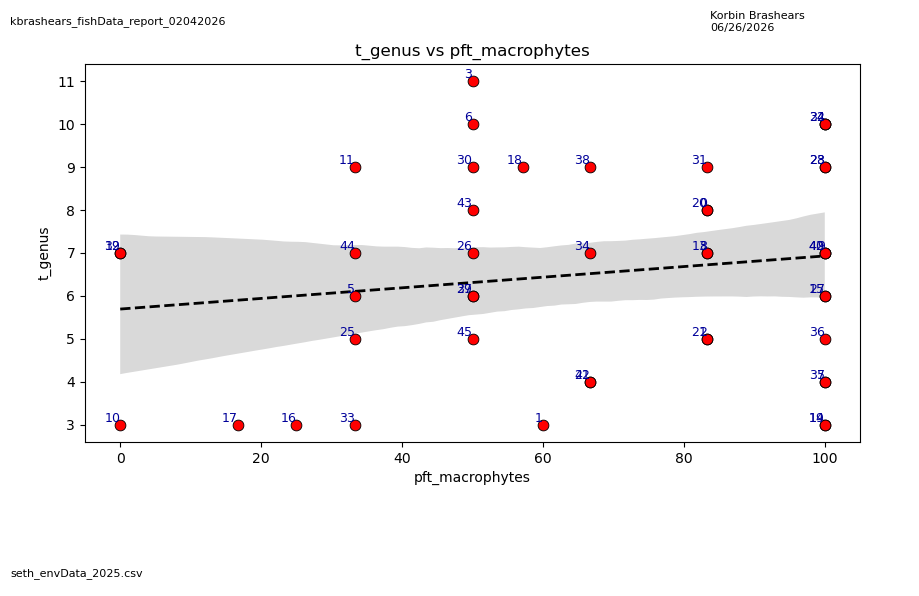

In [66]:
scatter_trendLine_plotter(s_ed['pft_macrophytes'], s_egcd['t_population'], save=False)         # calling the function to create scatter plots of pH

scatter_trendLine_plotter(s_ed['pft_macrophytes'], s_egcd['t_genus'], save=False)              # calling the function to create scatter plots of pH

## <a id='toc1_5_'></a>[Clustering Methods](#toc0_)

> Here I will using various methods of clustering, as well as with various features and parameters till I find consistent clusters.

### <a id='toc1_5_1_'></a>[Clustering Sites by envAtt](#toc0_)

c:\Users\Korbin\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


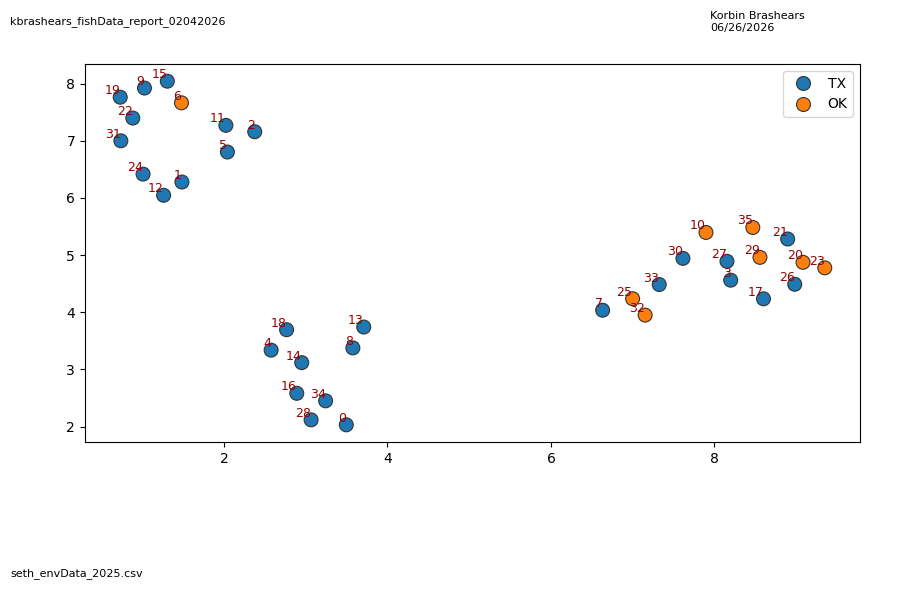

In [67]:

cf_c = s_ed.columns[4:]                                                   # selecting the environmental attribute columns for clustering

X = s_ed[cf_c].copy()                                                     # creating a new data frame with only the environmental attribute columns for clustering

le = LabelEncoder()                                                       # creating an instance of the LabelEncoder for encoding categorical variables
labels = s_erd['State'].astype(str)                                       # selecting the 'SiteN' column as the labels for encoding
y = le.fit_transform(labels)                                              # fitting the label encoder to the labels and transforming them into numerical format

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scalar = StandardScaler()                                                 # creating an instance of the StandardScaler for feature scaling
Xtr = scalar.fit_transform(X_train)                                       # fitting the scaler to the data and transforming it to have zero mean and unit variance
Xte = scalar.transform(X_test)                                            # fitting the scaler to the data and transforming it to have zero mean and unit variance


#----------------------------------------------------------------
# U-MAP Clustering
#----------------------------------------------------------------

umap_model = umap.UMAP(
    n_components=2, metric='correlation', random_state=30,
    n_neighbors=7, n_epochs=700, learning_rate=0.01, min_dist=0.1, n_jobs=2
)      

Xtr_umap = umap_model.fit_transform(Xtr)                                  # fitting the UMAP model to the training data and transforming it to 2 dimensions
Xte_umap = umap_model.transform(Xte)                                      # transforming the test data using the fitted UMAP model  

plt.figure(figsize=(10, 6))                                               # creating the figure for the UMAP plot with matplotlib
sns.scatterplot(x=Xtr_umap[:, 0], y=Xtr_umap[:, 1], hue=le.inverse_transform(y_train), palette='tab10', s=100, edgecolor='#333333')

# Adding Point Index Labels
for i in range(len(Xtr_umap[:, 0])):
    plt.text(Xtr_umap[i, 0], Xtr_umap[i, 1], str(i), fontsize=9, ha='right', va='bottom', color='#990000', zorder=3)       # adding index labels to each point

label_plot_edges(
    program_names="kbrashears_fishData_report_02042026",                                     # calling the function to label the edges of the plot
    author_names="Korbin Brashears", 
    data_filenames="seth_envData_2025.csv", 
    fig_filename="../figures/kbrashears_fishData_report_02042026/envAtt_siteCluster_umap.png",
    save = saveAll if saveAll else False                                                     # change False to True to save individual figure separately from saveAll
    )

plt.show()

## <a id='toc1_6_'></a>[Classifiers](#toc0_)

### <a id='toc1_6_1_'></a>[KNN Classifier](#toc0_)

## <a id='toc1_7_'></a>[Regression Models](#toc0_)

### <a id='toc1_7_1_'></a>[t_population & t_genus Regressors](#toc0_)

> Trying a Random Forrest Regressor and XGBoost and comparing results.




#### Creating the Models

In [68]:
# Random Forest models (good starting hyperparameters)
rf = RandomForestRegressor(n_estimators=300, random_state=42)

# XGBoost models (good starting hyperparameters)
xgb = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

#### <a id='toc1_7_1_1_'></a>[Random Forrest Regressor](#toc0_)

>> **Results**
>> This RF is really bad at predicting the t_population and also not good at predicting the t_genus.
>
>> **t_population**
>>
>> The R2_score for t_population is less than 0, meaning it is worse than predicting the mean population value every time.
>>
>> The MSE is also not good as it is easily effected by outliers and reflects that a RF is generally not good for data like ours.
>
>>**t_genus**
>>
>>The Random Forest performs better on predicting t_genus (total genus richness) than on t_population, but the results still show clear limitations.
>>
>>Genus richness is generally more predictable than total abundance because it reflects broader habitat suitability rather than fine‑scale stochastic processes. Even so, the model only achieves moderate performance, with an R² around 0.36–0.42 depending on whether evaluation is done in log‑space or original space.

In [69]:
# -----------------------------
# 1. Prepare data
# -----------------------------
cf_c = s_ed.columns[4:]
X = s_ed[cf_c].copy()

y_pop_log = np.log1p(s_egcd['t_population'])
y_gen_log = np.log1p(s_egcd['t_genus'])

# -----------------------------
# 2. Cross-validated predictions (in log space)
# -----------------------------
pred_pop_log = cross_val_predict(rf, X, y_pop_log, cv=5)
pred_gen_log = cross_val_predict(rf, X, y_gen_log, cv=5)

# -----------------------------
# 3A. Evaluate in LOG space
# -----------------------------
mse_pop_log = mean_squared_error(y_pop_log, pred_pop_log)
r2_pop_log = r2_score(y_pop_log, pred_pop_log)

mse_gen_log = mean_squared_error(y_gen_log, pred_gen_log)
r2_gen_log = r2_score(y_gen_log, pred_gen_log)

# -----------------------------
# 3B. Evaluate in ORIGINAL space
# -----------------------------
y_pop_raw = np.expm1(y_pop_log)
y_gen_raw = np.expm1(y_gen_log)

pred_pop_raw = np.expm1(pred_pop_log)
pred_gen_raw = np.expm1(pred_gen_log)

mse_pop_raw = mean_squared_error(y_pop_raw, pred_pop_raw)
r2_pop_raw = r2_score(y_pop_raw, pred_pop_raw)

mse_gen_raw = mean_squared_error(y_gen_raw, pred_gen_raw)
r2_gen_raw = r2_score(y_gen_raw, pred_gen_raw)


# ---------------------------
# 4. Print Results
# ---------------------------

print("LOG-SPACE EVALUATION")
print(f"Population: MSE={mse_pop_log:.3f}, R2={r2_pop_log:.3f}")
print(f"Genus:      MSE={mse_gen_log:.3f}, R2={r2_gen_log:.3f}")

print("\nORIGINAL-SPACE EVALUATION")
print(f"Population: MSE={mse_pop_raw:.3f}, R2={r2_pop_raw:.3f}")
print(f"Genus:      MSE={mse_gen_raw:.3f}, R2={r2_gen_raw:.3f}")

LOG-SPACE EVALUATION
Population: MSE=0.486, R2=-0.005
Genus:      MSE=0.066, R2=0.403

ORIGINAL-SPACE EVALUATION
Population: MSE=5118.892, R2=-0.007
Genus:      MSE=3.431, R2=0.357


#### <a id='toc1_7_1_2_'></a>[XGBoost](#toc0_)

> Trying an **XGBoost Regressor** on the same environmental predictors to compare performance against the Random Forest and Poisson Regression models.
>
>> **Results**  
>> XGBoost handles nonlinear relationships and skewed ecological data better than Random Forest, but the results still reflect the underlying difficulty of the prediction task.  
>>
>> **t_population**  
>>  
>> Even with XGBoost, the R² score for *t_population* remains **negative**, meaning the model performs worse than simply predicting the mean population at every site.  
>>  
>> This is expected: total fish abundance is highly stochastic and strongly influenced by unmeasured microhabitat, seasonal pulses, rare species, and sampling noise.  
>>  
>> **t_genus**  
>>  
>> XGBoost performs **moderately well** on *t_genus* (total genus richness), achieving a positive R² in both log‑space and original‑space evaluations.  
>>  
>> Richness is more predictable than total abundance because it reflects broader habitat suitability rather than fine‑scale stochastic processes.  
>>  
>> Even so, the model only achieves **moderate** predictive power, with R² values around **0.33–0.38**, depending on the evaluation scale.
>

In [70]:
# ---------------------------------------------------------
# 1. PREPARE DATA
# ---------------------------------------------------------

cf_c = s_ed.columns[4:]
X = s_ed[cf_c].copy()

# Log-transform targets
y_pop_log = np.log1p(s_egcd['t_population'])
y_gen_log = np.log1p(s_egcd['t_genus'])

# ---------------------------------------------------------
# 2. CROSS-VALIDATED PREDICTIONS (LOG SPACE)
# ---------------------------------------------------------

pred_pop_log = cross_val_predict(xgb, X, y_pop_log, cv=5)
pred_gen_log = cross_val_predict(xgb, X, y_gen_log, cv=5)

# ---------------------------------------------------------
# 3A. EVALUATE IN LOG SPACE
# ---------------------------------------------------------

mse_pop_log = mean_squared_error(y_pop_log, pred_pop_log)
r2_pop_log = r2_score(y_pop_log, pred_pop_log)

mse_gen_log = mean_squared_error(y_gen_log, pred_gen_log)
r2_gen_log = r2_score(y_gen_log, pred_gen_log)

# ---------------------------------------------------------
# 3B. EVALUATE IN ORIGINAL SPACE
# ---------------------------------------------------------

y_pop_raw = np.expm1(y_pop_log)
y_gen_raw = np.expm1(y_gen_log)

pred_pop_raw = np.expm1(pred_pop_log)
pred_gen_raw = np.expm1(pred_gen_log)

mse_pop_raw = mean_squared_error(y_pop_raw, pred_pop_raw)
r2_pop_raw = r2_score(y_pop_raw, pred_pop_raw)

mse_gen_raw = mean_squared_error(y_gen_raw, pred_gen_raw)
r2_gen_raw = r2_score(y_gen_raw, pred_gen_raw)


# ------------------------------------
# 4. PRINT RESULTS
# ------------------------------------

print("LOG-SPACE EVALUATION")
print(f"Population: MSE={mse_pop_log:.3f}, R2={r2_pop_log:.3f}")
print(f"Genus:      MSE={mse_gen_log:.3f}, R2={r2_gen_log:.3f}")

print("\nORIGINAL-SPACE EVALUATION")
print(f"Population: MSE={mse_pop_raw:.3f}, R2={r2_pop_raw:.3f}")
print(f"Genus:      MSE={mse_gen_raw:.3f}, R2={r2_gen_raw:.3f}")


LOG-SPACE EVALUATION
Population: MSE=0.590, R2=-0.220
Genus:      MSE=0.073, R2=0.340

ORIGINAL-SPACE EVALUATION
Population: MSE=6220.581, R2=-0.224
Genus:      MSE=3.560, R2=0.333


#### <a id='toc1_7_2_1_'></a>[X = Site Attributes](#toc0_)

>> **Genus‑Level Prediction Results (XGBoost)**  
>> After training one XGBoost model per genus and evaluating performance using 5‑fold cross‑validated predictions, the results show a clear ecological pattern:
>>
>> - A **small number of genera** exhibit *moderate predictability* (positive R² in log‑space).  
>> - **Most genera** show *negative R²*, meaning their abundances cannot be predicted from the available environmental variables.  
>> - This is expected: many stream fish genera are rare, patchy, zero‑inflated, or driven by microhabitat and biotic interactions not captured in the dataset.
>>
>> **Most Predictable Genera (R²_log > 0.20)**  
>> - *Etheostoma* — R²_log = 0.334  
>> - *Cyprinella* — R²_log = 0.252  
>> - *Campostoma* — R²_log = 0.248  
>>
>> These genera respond to broad habitat gradients (flow, slope, substrate), which aligns with ecological expectations.
>>
>> **Weakly Predictable Genera (0 < R²_log < 0.20)**  
>> - None with strong signal, though a few genera hover near zero.
>>
>> **Unpredictable Genera (R²_log < 0)**  
>> Examples include:  
>> - *Percina* — R²_log = –0.633  
>> - *Lepomis* — R²_log = –0.394  
>> - *Fundulus* — R²_log = –0.442  
>> - *Noturus* — R²_log = –1.397  
>> - *Semotilus* — R²_log = –2.910  
>>
>> These genera are either rare, highly patchy, or driven by microhabitat features not represented in the predictor set. Negative R² values are not errors — they indicate that predicting the mean abundance would outperform the model.
>>
>> **Interpretation**  
>> The results reveal that only a subset of genera exhibit predictable abundance patterns from watershed‑scale environmental variables. This is consistent with ecological theory: richness is predictable, but abundance is dominated by stochasticity, local habitat structure, and species‑specific behaviors.
>>
>> **Conclusion**  
>> The Stage‑2 genus distribution model will proceed using:  
>> - environmental predictors  
>> - **predicted t_genus** from Stage‑1  
>>
>> This stacked modeling approach provides the most stable and ecologically defensible framework for predicting site‑level fish community composition.

### Habitability Binary Regressors

> Habitability here will be defined as a binary term referring to a site having a greater t_population than a given Threshold.

> In the code I will have a pop_habitability and a gen_habitability referring to t_population and t_genus respectively.

### <a id='toc1_7_2_'></a>[Site Genus Distribution Regressor](#toc0_)

> I will move on only using the **t_genus** predictions from the XGBoost model, as it was the only partially reliable Stage‑1 metric.  
> Total population (`t_population`) was effectively unpredictable across all models, while genus richness (`t_genus`) showed moderate, ecologically meaningful signal.



#### Model Creation

In [71]:
# XGBoost model
model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

In [72]:
# ---------------------------------------------------------
# 1. PREPARE DATA
# ---------------------------------------------------------

# Environmental predictors
cf_c = s_ed.columns[4:]
X = s_ed[cf_c].copy()

# Stage-1 predicted richness (use your XGB richness model output)
X2 = X.copy()
X2["pred_t_genus"] = pred_gen_log   # or pred_gen_raw, depending on your choice

# Genus abundance matrix
genus_cols = s_gcd.columns[2:]   # adjust if needed
Y = s_gcd[genus_cols].copy()

# ---------------------------------------------------------
# 2. FUNCTION TO TRAIN + EVALUATE ONE GENUS
# ---------------------------------------------------------

def evaluate_genus(genus_name):
    """Train an XGBoost model for one genus and return metrics + predictions."""
    
    # Target: log-abundance
    y_raw = Y[genus_name].values
    y_log = np.log1p(y_raw)

    # Cross-validated predictions (log-space)
    pred_log = cross_val_predict(model, X2, y_log, cv=5)

    # Convert back to raw abundance
    pred_raw = np.expm1(pred_log)

    # Metrics in log-space
    mse_log = mean_squared_error(y_log, pred_log)
    r2_log = r2_score(y_log, pred_log)

    # Metrics in original space
    mse_raw = mean_squared_error(y_raw, pred_raw)
    r2_raw = r2_score(y_raw, pred_raw)

    return {
        "genus": genus_name,
        "mse_log": mse_log,
        "r2_log": r2_log,
        "mse_raw": mse_raw,
        "r2_raw": r2_raw,
        "pred_raw": pred_raw
    }

# ---------------------------------------------------------
# 3. LOOP OVER ALL GENERA AND STORE RESULTS
# ---------------------------------------------------------

results = []
for genus in genus_cols:
    res = evaluate_genus(genus)
    results.append(res)

results_df = pd.DataFrame(results)

# Sort by R² (best to worst)
results_df_sorted = results_df.sort_values("r2_log", ascending=False)

results_df_sorted.to_csv("../data/kbrashears_fishData_report_02042026/genus_attributes_prediction_results.csv", index=False)

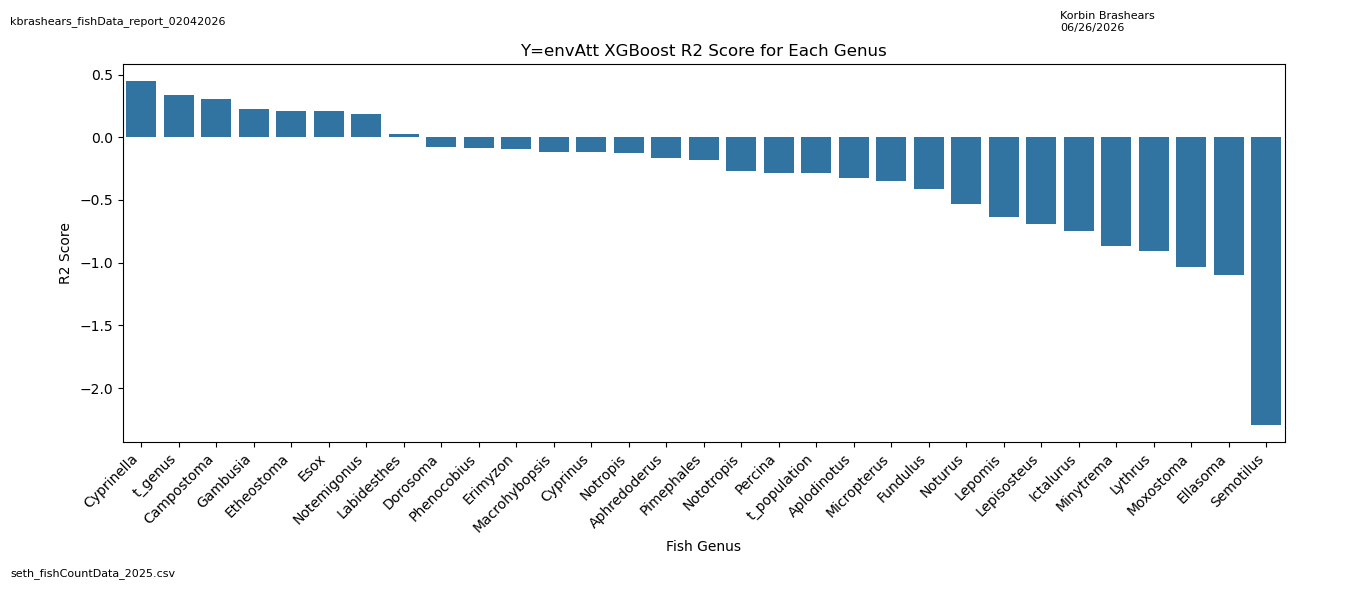

In [73]:
# ================================================= Loading Data ===========================================================

gp_r = pd.read_csv("../data/kbrashears_fishData_report_02042026/genus_attributes_prediction_results.csv")     # loading the genus prediction results data frame    

# ================================================== Data Analysis =========================================================

X = gp_r['genus']                                                                                 # selecting the 'genus' column as the x-axis values for plotting
Y = gp_r['r2_log']                                                                                 # selecting the 'r2_log'

# ====================================================== Plotting ==========================================================

plt.figure(figsize=(15, 6))                                             # creating the figure for the bar plot with matplotlib
sns.barplot(x=X, y=Y)        # creating the bar plot with seaborn
plt.xticks(rotation=45, ha='right')                                     # rotating x-axis labels for better readability and aligning them to the right
plt.xlabel('Fish Genus')                                              # setting x-axis label
plt.ylabel('R2 Score')                                               # setting y-axis label
plt.title('Y=envAtt XGBoost R2 Score for Each Genus')                           # setting the title of the plot

label_plot_edges(
    program_names="kbrashears_fishData_report_02042026",                # calling the function to label the edges of the plot
    author_names="Korbin Brashears", 
    data_filenames="seth_fishCountData_2025.csv", 
    fig_filename="../figures/kbrashears_fishData_report_02042026/envAtt_prediction_r2_barPlot.png",
    save = saveAll if saveAll else False                                # change False to True to save individual figure separately from saveAll
    )  

plt.show()                                                              # displaying the plot

#### <a id='toc1_7_2_2_'></a>[X = Genus Distribution](#toc0_)

In [74]:
# ---------------------------------------------------------
# 1. PREPARE DATA
# ---------------------------------------------------------

# Environmental predictors
cf_c = s_gcd.columns[2:]
X = s_gcd[cf_c].copy()

# Stage-1 predicted richness (use your XGB richness model output)
# If you already have pred_genus_log or pred_genus_raw, insert it here.
# For now, I'll assume you have it as "pred_t_genus"
X2 = X.copy()
X2["pred_t_genus"] = pred_gen_log   # or pred_gen_raw, depending on your choice

# Genus abundance matrix
genus_cols = s_gcd.columns[2:]   # adjust if needed
Y = s_gcd[genus_cols].copy()

# ---------------------------------------------------------
# 2. FUNCTION TO TRAIN + EVALUATE ONE GENUS
# ---------------------------------------------------------

def evaluate_genus(genus_name):
    """Train an XGBoost model for one genus and return metrics + predictions."""
    
    X.drop(columns=[genus_name], inplace=True)  # Remove the target genus from predictors to avoid data leakage
    
    # Target: log-abundance
    y_raw = Y[genus_name].values
    y_log = np.log1p(y_raw)

    # XGBoost model
    model = XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    )

    # Cross-validated predictions (log-space)
    pred_log = cross_val_predict(model, X2, y_log, cv=5)

    # Convert back to raw abundance
    pred_raw = np.expm1(pred_log)

    # Metrics in log-space
    mse_log = mean_squared_error(y_log, pred_log)
    r2_log = r2_score(y_log, pred_log)

    # Metrics in original space
    mse_raw = mean_squared_error(y_raw, pred_raw)
    r2_raw = r2_score(y_raw, pred_raw)

    return {
        "genus": genus_name,
        "mse_log": mse_log,
        "r2_log": r2_log,
        "mse_raw": mse_raw,
        "r2_raw": r2_raw,
        "pred_raw": pred_raw
    }

# ---------------------------------------------------------
# 3. LOOP OVER ALL GENERA AND STORE RESULTS
# ---------------------------------------------------------

results = []
for genus in genus_cols:
    res = evaluate_genus(genus)
    results.append(res)

results_df = pd.DataFrame(results)

# Sort by R² (best to worst)
results_df_sorted = results_df.sort_values("r2_log", ascending=False)

results_df_sorted.to_csv("../data/kbrashears_fishData_report_02042026/genus_genus_prediction_results.csv", index=False)

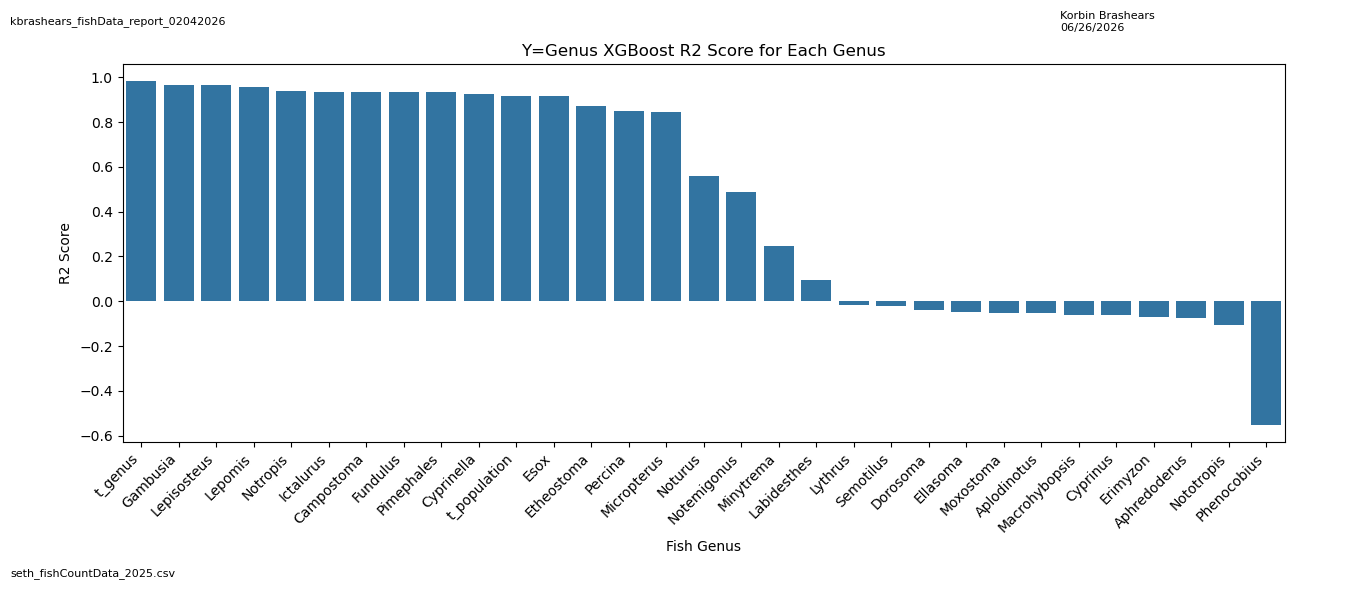

In [75]:
# ================================================= Loading Data ===========================================================

gp_r = pd.read_csv("../data/kbrashears_fishData_report_02042026/genus_genus_prediction_results.csv")     # loading the genus prediction results data frame    

# ================================================== Data Analysis =========================================================

X = gp_r['genus']                                                                                 # selecting the 'genus' column as the x-axis values for plotting
Y = gp_r['r2_log']                                                                                 # selecting the 'r2_log'

# ====================================================== Plotting ==========================================================

plt.figure(figsize=(15, 6))                                             # creating the figure for the bar plot with matplotlib
sns.barplot(x=X, y=Y)        # creating the bar plot with seaborn
plt.xticks(rotation=45, ha='right')                                     # rotating x-axis labels for better readability and aligning them to the right
plt.xlabel('Fish Genus')                                              # setting x-axis label
plt.ylabel('R2 Score')                                               # setting y-axis label
plt.title('Y=Genus XGBoost R2 Score for Each Genus')                           # setting the title of the plot

label_plot_edges(
    program_names="kbrashears_fishData_report_02042026",                # calling the function to label the edges of the plot
    author_names="Korbin Brashears", 
    data_filenames="seth_fishCountData_2025.csv", 
    fig_filename="../figures/kbrashears_fishData_report_02042026/genus_prediction_r2_barPlot.png",
    save = saveAll if saveAll else False                                # change False to True to save individual figure separately from saveAll
    )

plt.show()                                                              # displaying the plot

#### <a id='toc1_7_2_3_'></a>[Fish Genus Correlation Heat Map](#toc0_)

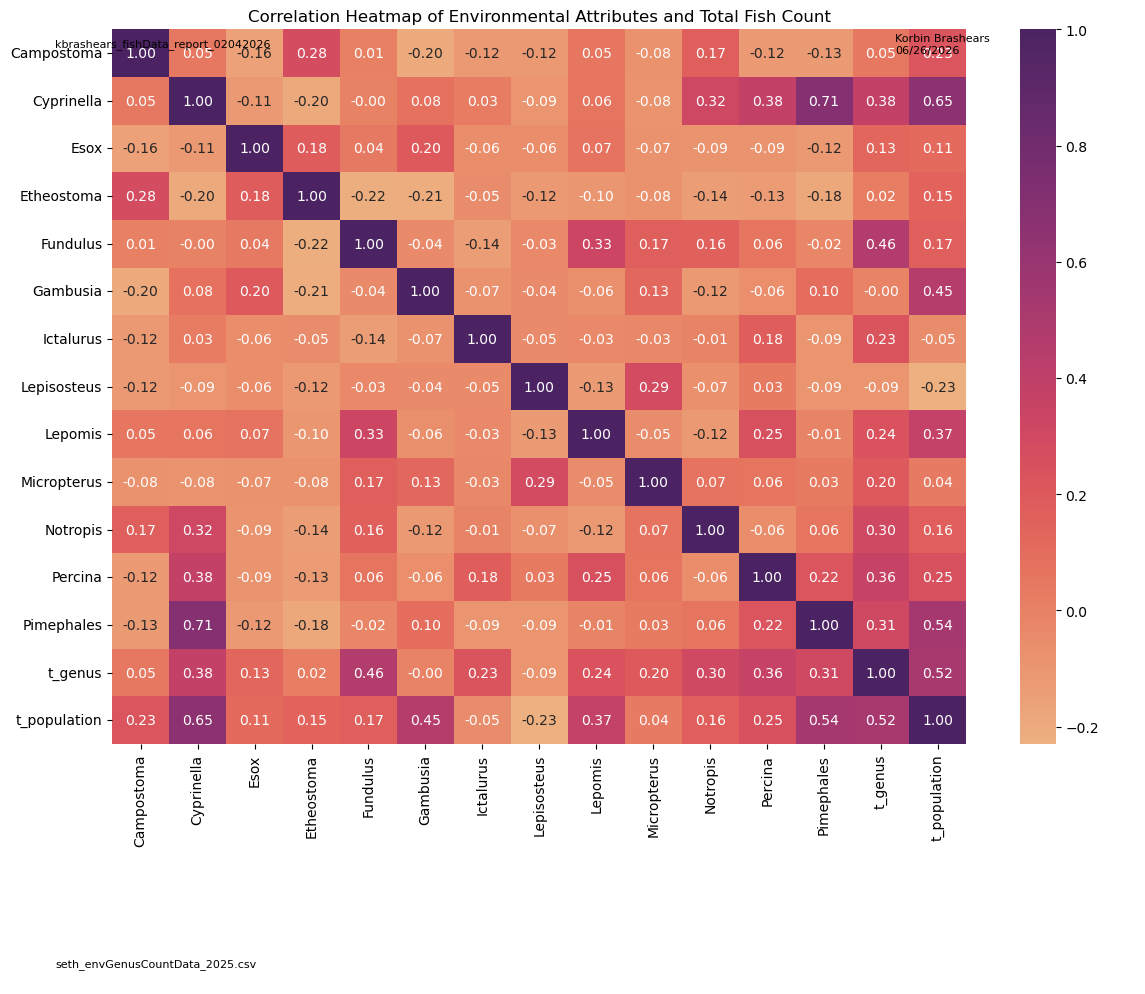

In [76]:
# ===================================================== Data Analysis ===========================================================

# Selecting Attribute Columns and Fish Count Columns
att_cols = results_df[results_df["r2_log"] > 0.75]["genus"].tolist()     # extracting the names of the genera with R² greater than 0.75 for further analysis

# Calculating Correlation Matrix
s_ed_c_m = s_egcd[att_cols].corr(numeric_only=True)                                          # calculating the correlation matrix for the environmental attributes

# ===================================================== Plotting =================================================================

# Creating Figure
plt.figure(figsize=(12, 10))                                                                 # creating the figure for the heatmap with matplotlib

# Creating Heatmap
sns.heatmap(s_ed_c_m, annot=True, cmap='flare', fmt='.2f')                                   # creating the heatmap with seaborn using the correlation matrix, annotating the values, and using the 'coolwarm' color map

plt.title('Correlation Heatmap of Environmental Attributes and Total Fish Count')            # setting the title of the plot

plt.tight_layout()                                                                           # adjusting the layout to prevent overlap

label_plot_edges(
    program_names="kbrashears_fishData_report_02042026",                                     # calling the function to label the edges of the plot
    author_names="Korbin Brashears", 
    data_filenames="seth_envGenusCountData_2025.csv", 
    fig_filename="../figures/kbrashears_fishData_report_02042026/genus_correlation_heatmap.png",
    save = saveAll if saveAll else False                                                     # change False to True to save individual figure separately from saveAll
    )

plt.show()

#### <a id='toc1_7_2_4_'></a>[X = Time Metrics](#toc0_)

In [77]:
# ---------------------------------------------------------
# 1. PREPARE DATA
# ---------------------------------------------------------

# Environmental predictors
cf_c = g_edm.columns[1:]
X = g_edm[cf_c].copy()

# Stage-1 predicted richness (use your XGB richness model output)
# If you already have pred_genus_log or pred_genus_raw, insert it here.
# For now, I'll assume you have it as "pred_t_genus"
X2 = X.copy()
X2["pred_t_genus"] = pred_gen_log   # or pred_gen_raw, depending on your choice

# Genus abundance matrix
genus_cols = s_gcd.columns[2:]   # adjust if needed
Y = s_gcd[genus_cols].copy()

# ---------------------------------------------------------
# 2. FUNCTION TO TRAIN + EVALUATE ONE GENUS
# ---------------------------------------------------------

def evaluate_genus(genus_name):
    """Train an XGBoost model for one genus and return metrics + predictions."""
    
    # Target: log-abundance
    y_raw = Y[genus_name].values
    y_log = np.log1p(y_raw)

    # XGBoost model
    model = XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    )

    # Cross-validated predictions (log-space)
    pred_log = cross_val_predict(model, X2, y_log, cv=5)

    # Convert back to raw abundance
    pred_raw = np.expm1(pred_log)

    # Metrics in log-space
    mse_log = mean_squared_error(y_log, pred_log)
    r2_log = r2_score(y_log, pred_log)

    # Metrics in original space
    mse_raw = mean_squared_error(y_raw, pred_raw)
    r2_raw = r2_score(y_raw, pred_raw)

    return {
        "genus": genus_name,
        "mse_log": mse_log,
        "r2_log": r2_log,
        "mse_raw": mse_raw,
        "r2_raw": r2_raw,
        "pred_raw": pred_raw
    }

# ---------------------------------------------------------
# 3. LOOP OVER ALL GENERA AND STORE RESULTS
# ---------------------------------------------------------

results = []
for genus in genus_cols:
    res = evaluate_genus(genus)
    results.append(res)

results_df = pd.DataFrame(results)

# Sort by R² (best to worst)
results_df_sorted = results_df.sort_values("r2_log", ascending=False)

results_df_sorted.to_csv("../data/kbrashears_fishData_report_02042026/genus_tsMetrics_prediction_results.csv", index=False)

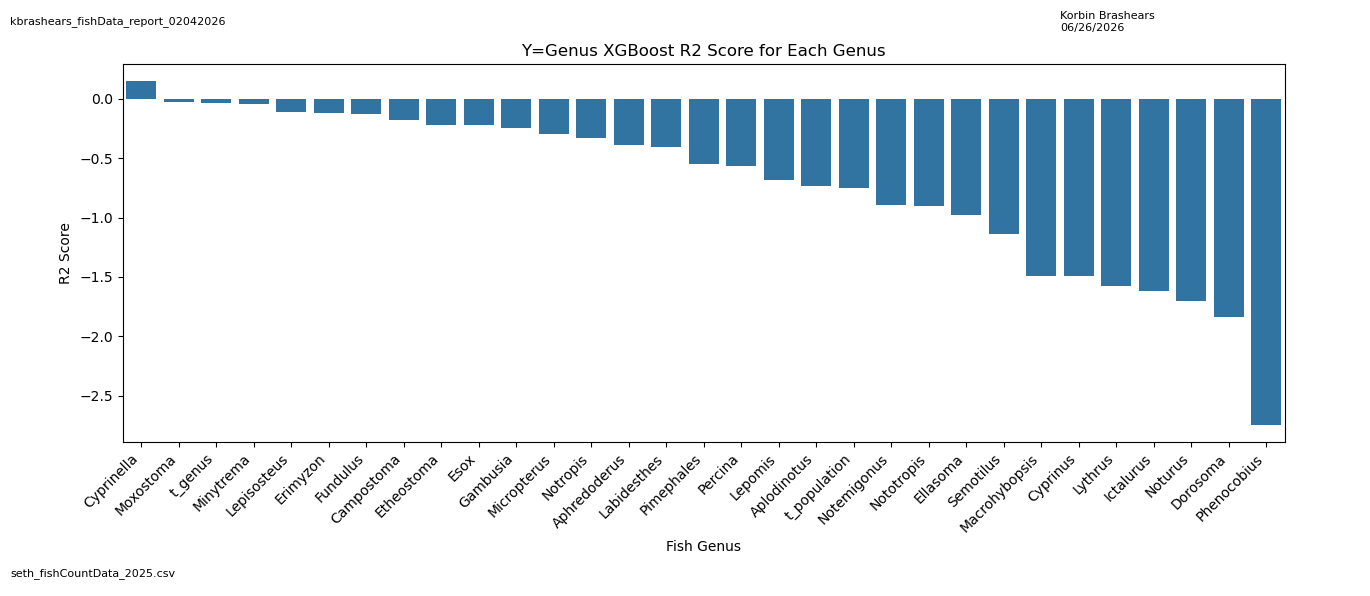

In [78]:
# ================================================= Loading Data ===========================================================

gp_r = pd.read_csv("../data/kbrashears_fishData_report_02042026/genus_tsMetrics_prediction_results.csv")     # loading the genus prediction results data frame    

# ================================================== Data Analysis =========================================================

X = gp_r['genus']                                                                                 # selecting the 'genus' column as the x-axis values for plotting
Y = gp_r['r2_log']                                                                                 # selecting the 'r2_log'

# ====================================================== Plotting ==========================================================

plt.figure(figsize=(15, 6))                                             # creating the figure for the bar plot with matplotlib
sns.barplot(x=X, y=Y)        # creating the bar plot with seaborn
plt.xticks(rotation=45, ha='right')                                     # rotating x-axis labels for better readability and aligning them to the right
plt.xlabel('Fish Genus')                                              # setting x-axis label
plt.ylabel('R2 Score')                                               # setting y-axis label
plt.title('Y=Genus XGBoost R2 Score for Each Genus')                           # setting the title of the plot

label_plot_edges(
    program_names="kbrashears_fishData_report_02042026",                # calling the function to label the edges of the plot
    author_names="Korbin Brashears", 
    data_filenames="seth_fishCountData_2025.csv", 
    fig_filename="../figures/kbrashears_fishData_report_02042026/genus_prediction_r2_barPlot.png",
    save = saveAll if saveAll else False                                # change False to True to save individual figure separately from saveAll
    )

plt.show()                                                              # displaying the plot

### <a id='toc1_7_3_'></a>[Site Genus Presence Binary Regressors](#toc0_)

#### Model Creation

In [79]:
model = XGBClassifier(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    )

#### Function evaluate_genus_classification

In [80]:
def evaluate_genus_classification(X, csvFileName, plotFileName, saveCsv=True, savePlot=True):
    
    # ---------------------------------------------------------
    # 1. PREPARE DATA
    # ---------------------------------------------------------

    # Stage-1 predicted richness (use your XGB richness model output)
    X["pred_t_genus"] = pred_gen_log   # or pred_gen_raw, depending on your choice

    # Genus abundance matrix
    genus_cols = s_gcd.columns[2:]   # adjust if needed
    Y = (s_gcd[genus_cols] > 0).astype(int).copy()

    # ---------------------------------------------------------
    # 2. FUNCTION TO TRAIN + EVALUATE ONE GENUS
    # ---------------------------------------------------------

    def evaluate_genus(genus_name):
        y = Y[genus_name].values
        
        if genus_name in X.columns: X.drop(columns=[genus_name], inplace=True)  # Remove the target genus from predictors to avoid data leakage

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        pred_proba = np.zeros(len(y))

        for train_idx, test_idx in skf.split(X, y):
            model.fit(X.iloc[train_idx], y[train_idx])
            pred_proba[test_idx] = model.predict_proba(X.iloc[test_idx])[:, 1]

        pred_class = (pred_proba >= 0.5).astype(int)

        auc = roc_auc_score(y, pred_proba)
        acc = accuracy_score(y, pred_class)
        f1 = f1_score(y, pred_class)

        return {
            "genus": genus_name,
            "auc": auc,
            "accuracy": acc,
            "f1": f1,
            "pred_proba": pred_proba
        }

    # ---------------------------------------------------------
    # 3. LOOP OVER ALL GENERA AND STORE RESULTS
    # ---------------------------------------------------------

    results = []
    for genus in genus_cols:
        res = evaluate_genus(genus)
        results.append(res)

    results_df = pd.DataFrame(results)

    # Sort by auc (best to worst)
    results_df_sorted = results_df.sort_values("auc", ascending=False)

    if saveCsv: results_df_sorted.to_csv(csvFileName, index=False)

    # ====================================================== Plotting ==========================================================

    X = results_df_sorted['genus']          # x-axis: genus names
    Y = results_df_sorted['auc']            # y-axis: AUC scores (primary metric)

    plt.figure(figsize=(15, 6))
    sns.barplot(x=X, y=Y)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Fish Genus')
    plt.ylabel('AUC Score')
    plt.title('Genus Presence/Absence Predictability (AUC) Using XGBoost')

    label_plot_edges(
        program_names="kbrashears_fishData_report_02042026",
        author_names="Korbin Brashears",
        data_filenames="seth_fishCountData_2025.csv",
        fig_filename=plotFileName,
        save=saveAll if saveAll else savePlot
    )

    plt.show()

#### <a id='toc1_7_3_1_'></a>[X = Site Attributes](#toc0_)

In [81]:
# Environmental predictors
cf_c = s_ed.columns[4:]
X = s_ed[cf_c].copy()

evaluate_genus_classification(
    X,
    "../data/kbrashears_fishData_report_02042026/genus_attributes_bin_prediction_results.csv",
    "../figures/kbrashears_fishData_report_02042026/genus_attributes_bin_prediction_results.png",
    saveCsv=True,
    savePlot=True
    )

c:\Users\Korbin\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Korbin\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Korbin\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Korbin\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Korbin\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Korbin\anaconda3

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0], got [1]

#### <a id='toc1_7_3_2_'></a>[X = Genus Distribution](#toc0_)

c:\Users\Korbin\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Korbin\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Korbin\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Korbin\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Korbin\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Korbin\anaconda3

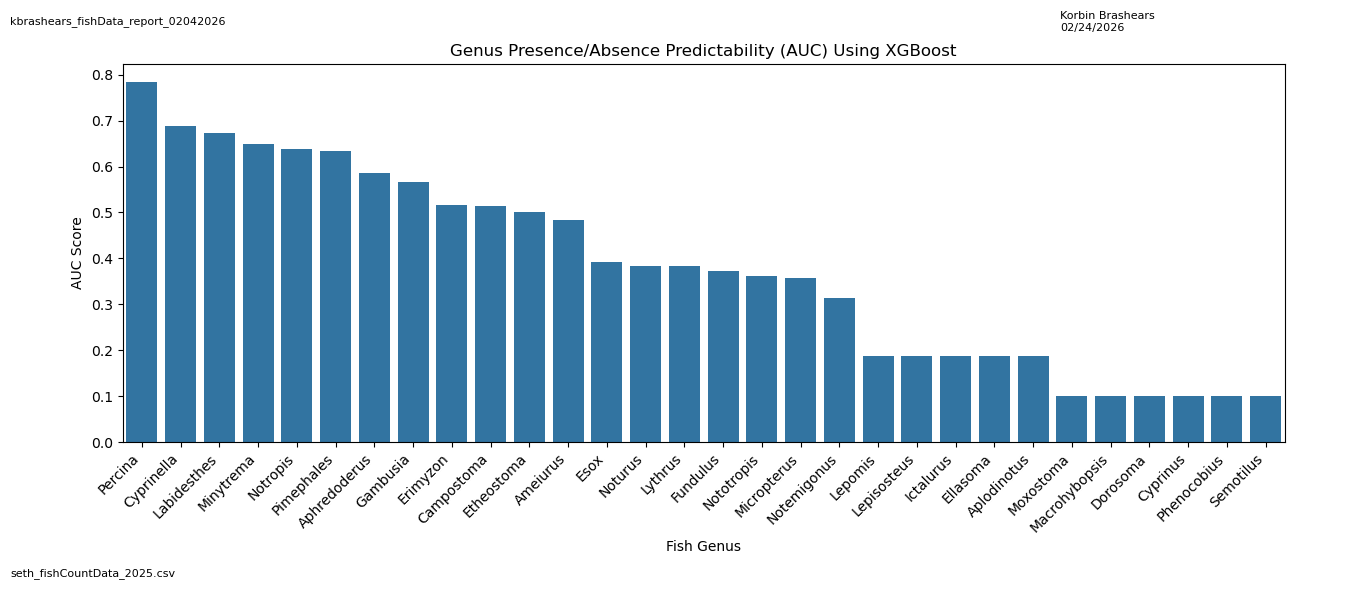

In [ ]:
# Genus predictors (all genus except the target)
cf_c = s_gcd.columns[2:]
X = s_gcd[cf_c].copy()

evaluate_genus_classification(
    X,
    "../data/kbrashears_fishData_report_02042026/genus_genus_bin_prediction_results.csv",
    "../figures/kbrashears_fishData_report_02042026/genus_genus_bin_prediction_results.png",
    saveCsv=True,
    savePlot=True
    )

#### <a id='toc1_7_3_3_'></a>[X = Time Metrics](#toc0_)

c:\Users\Korbin\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Korbin\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Korbin\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Korbin\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Korbin\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Korbin\anaconda3

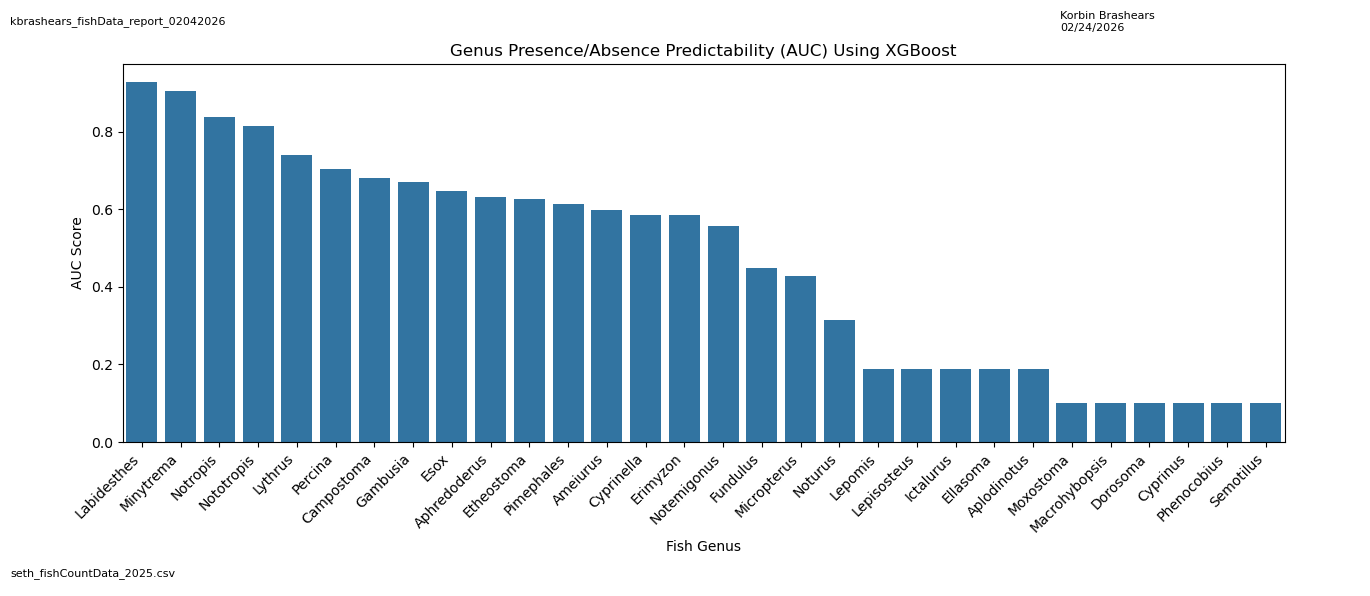

In [ ]:
# Time Series predictors
cf_c = g_edm.columns[1:]
X = g_edm[cf_c].copy()

evaluate_genus_classification(
    X,
    "../data/kbrashears_fishData_report_02042026/genus_tsMetrics_bin_prediction_results.csv",
    "../figures/kbrashears_fishData_report_02042026/genus_tsMetrics_bin_prediction_results.png",
    saveCsv=True,
    savePlot=True
    )

#### <a id='toc1_7_3_4_'></a>[X Value Comparison](#toc0_)

                      model  mean_auc
0  Environmental Attributes  0.488439
1        Genus Distribution  0.399825
2       Time-Series Metrics  0.461917


C:\Users\Korbin\AppData\Local\Temp\ipykernel_68328\317726210.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="model", y="mean_auc", palette="viridis")


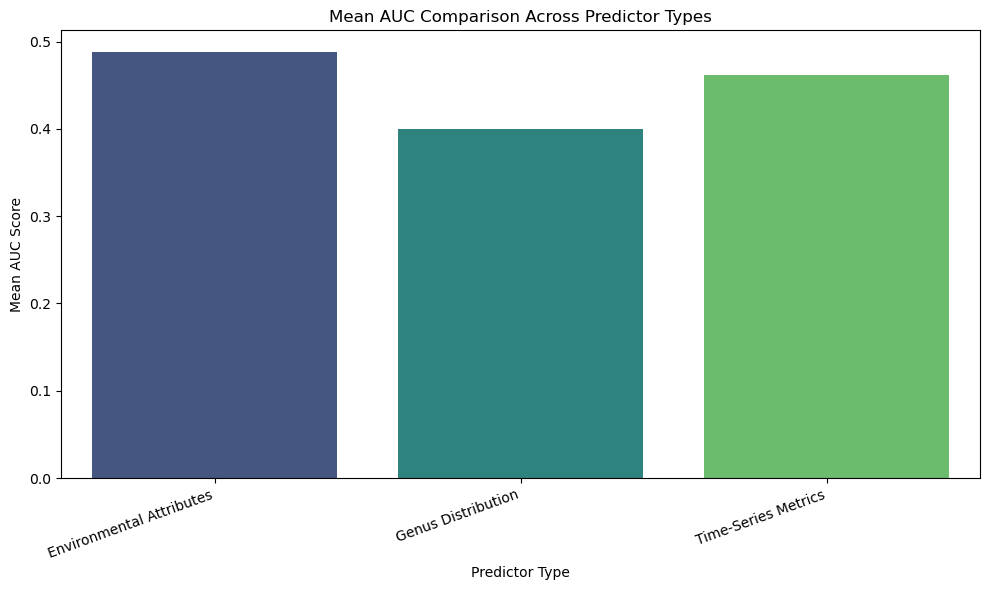

In [ ]:
# ---------------------------------------------------------
# 1. LOAD RESULTS
# ---------------------------------------------------------

gp_stt   = pd.read_csv("../data/kbrashears_fishData_report_02042026/genus_attributes_prediction_bin_results.csv")
gp_genus = pd.read_csv("../data/kbrashears_fishData_report_02042026/genus_genus_bin_prediction_results.csv")
gp_tsm   = pd.read_csv("../data/kbrashears_fishData_report_02042026/genus_tsMetrics_bin_prediction_results.csv")

# ---------------------------------------------------------
# 2. BUILD SUMMARY TABLE
# ---------------------------------------------------------

summary = pd.DataFrame({
    "model": ["Environmental Attributes", "Genus Distribution", "Time-Series Metrics"],
    "mean_auc": [
        gp_stt["auc"].mean(),
        gp_genus["auc"].mean(),
        gp_tsm["auc"].mean()
    ]
})

print(summary)

# ---------------------------------------------------------
# 3. PLOT COMPARISON
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.barplot(data=summary, x="model", y="mean_auc", palette="viridis")

plt.title("Mean AUC Comparison Across Predictor Types")
plt.xlabel("Predictor Type")
plt.ylabel("Mean AUC Score")
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.show()


## <a id='toc1_8_'></a>[A Focus on Orange Belly Darters](#toc0_)

> Seth has stated that Etheostoma Radiosum, ore the Orange Belly Darter, is of conservation interest, so I will be taking a moment to create some visualizations specifically on them.

### <a id='toc1_8_1_'></a>[Etheostoma Radiosum Distribution](#toc0_)

> An interesting observation from this plot shows that the orange belly darter is primarily present in OK, with almost no sites in the TX region has any.

> I will try to run **site_attributes_bar_plotter()** on the some of the significant TX sites containing the Orange Belly Darter, as well as some of the sites in OK and compare features.

>**POTENTIAL FUTURE SIGNIFICANCE**
> Look at the day time series metrics to see any significant changes in the TX sites neat to the OK border

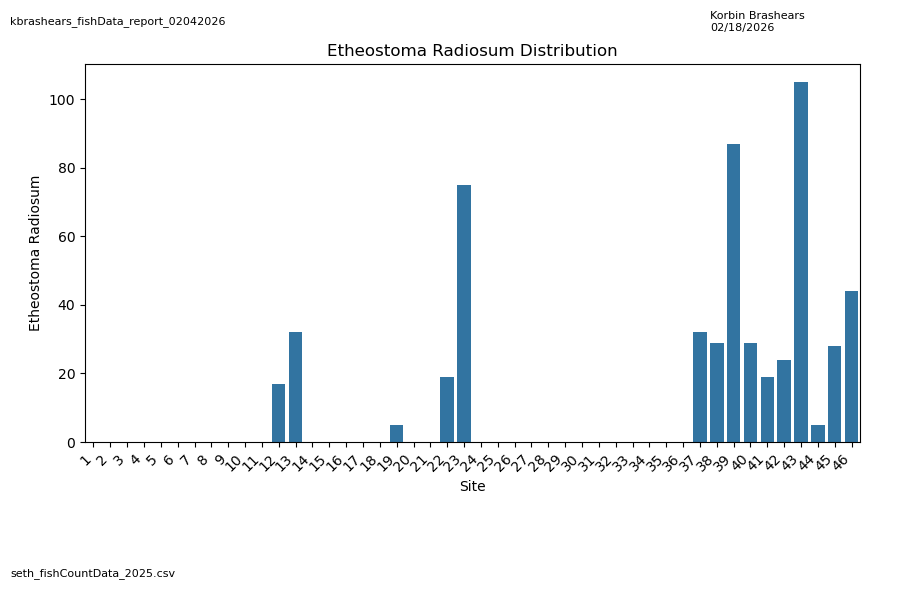

In [ ]:

plt.figure(figsize=(10, 6))                                               # creating the figure for the plot with matplotlib

sns.barplot(x=s_fcd['SiteN'], y=s_fcd['Etheostoma_radiosum'])             # creating the bar plot with seaborn

plt.xticks(rotation=45, ha='right')                                     # rotating x-axis labels for better readability and aligning them to the right

plt.xlabel('Site')                                              # setting x-axis label
plt.ylabel('Etheostoma Radiosum')                                               # setting y-axis label
plt.title('Etheostoma Radiosum Distribution')                           # setting the title of the plot

label_plot_edges(
    program_names="kbrashears_fishData_report_02042026",                # calling the function to label the edges of the plot
    author_names="Korbin Brashears", 
    data_filenames="seth_fishCountData_2025.csv", 
    fig_filename="../figures/kbrashears_fishData_report_02042026/etheostomaRadiosum_distribution_barPlot.png",
    save = saveAll if saveAll else False                                # change False to True to save individual figure separately from saveAll
    ) 

plt.show()

### <a id='toc1_8_2_'></a>[Sites Attributes with High Orange Belly Darter Count](#toc0_)

> Taking a closer look into sites that have a high count of Etheostoma Radiosum using **site_attributes_bar_plotter**.

> Site 39 is the site with the most Etheostoma Radiosum over all.
> Site 23 seems to be an outlier with a high count but located in Texas.

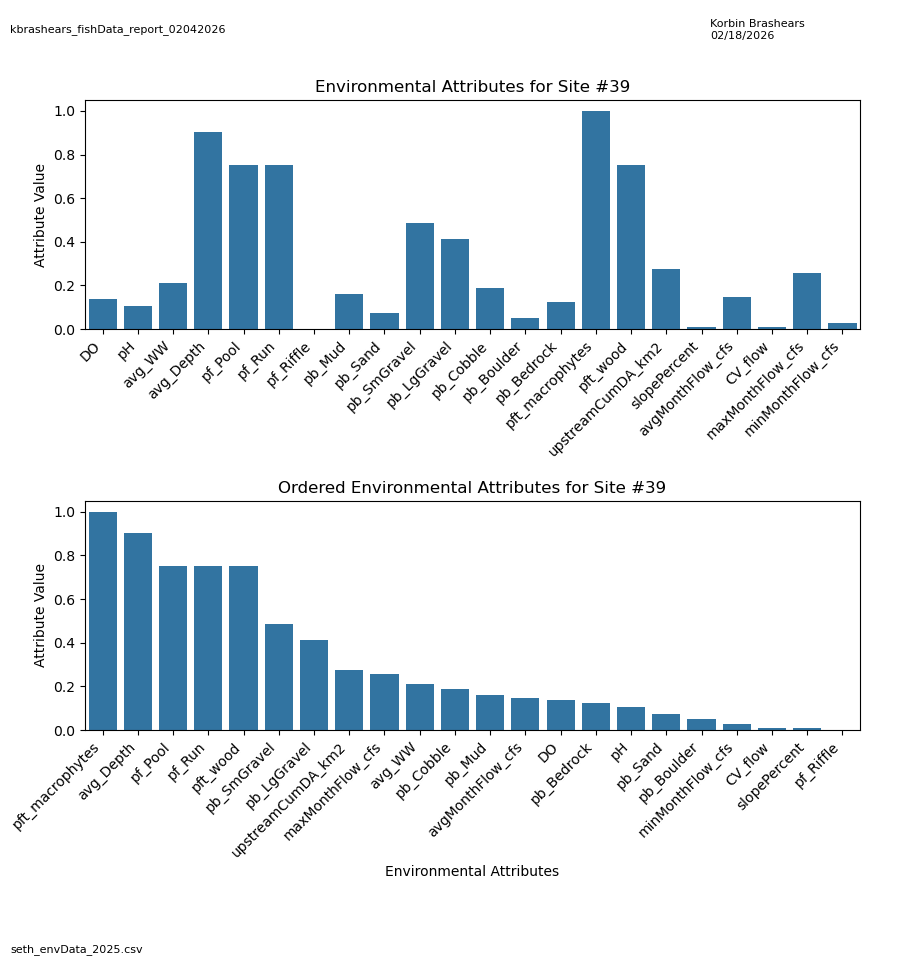

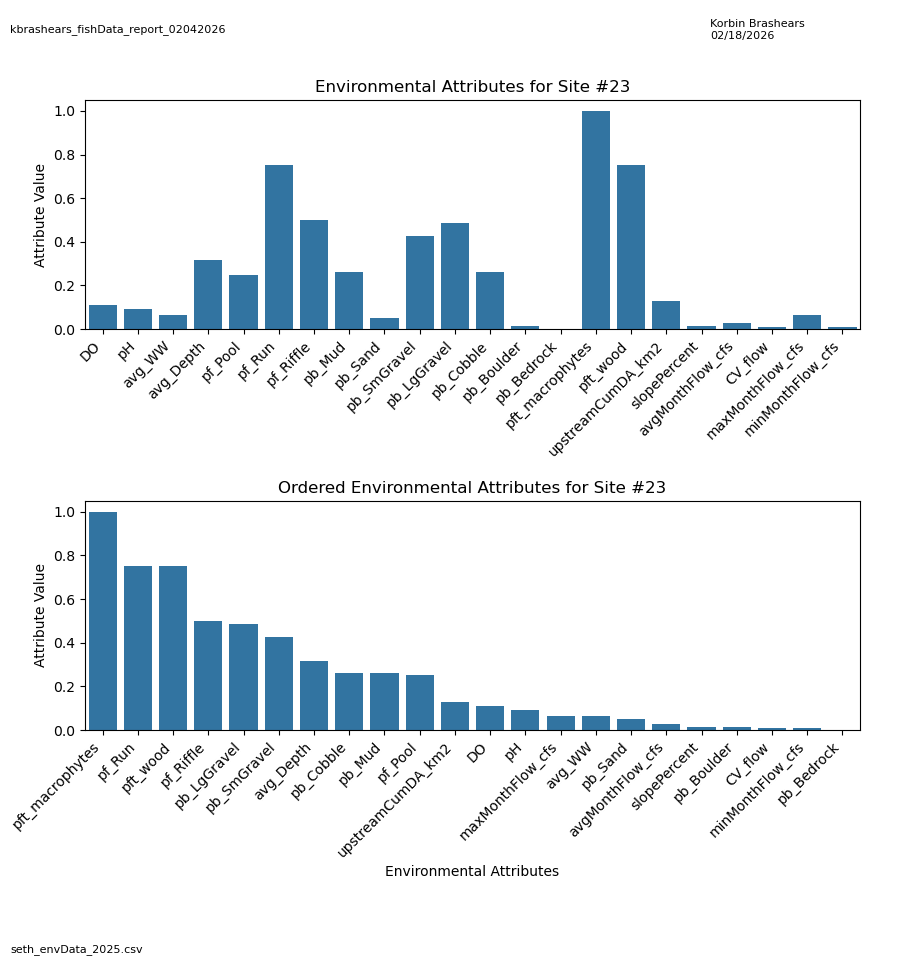

In [ ]:
# Site 39
site_attributes_bar_plotter(siteN=39, save=False)       # calling the function to create bar plots of environmental attributes

# Site 23
site_attributes_bar_plotter(siteN=23, save=False)       # calling the function to create bar plots of environmental attributes

### <a id='toc1_8_3_'></a>[Correlation Decay Plot With Site Attributes](#toc0_)

> Correlation decay plot shows the most correlated attributes, x, to a feature, y, from highest to lowest. The correlation is in absolute value to make it easier to see the correlation, but the negatives are shown in orange to see inverse correlations.

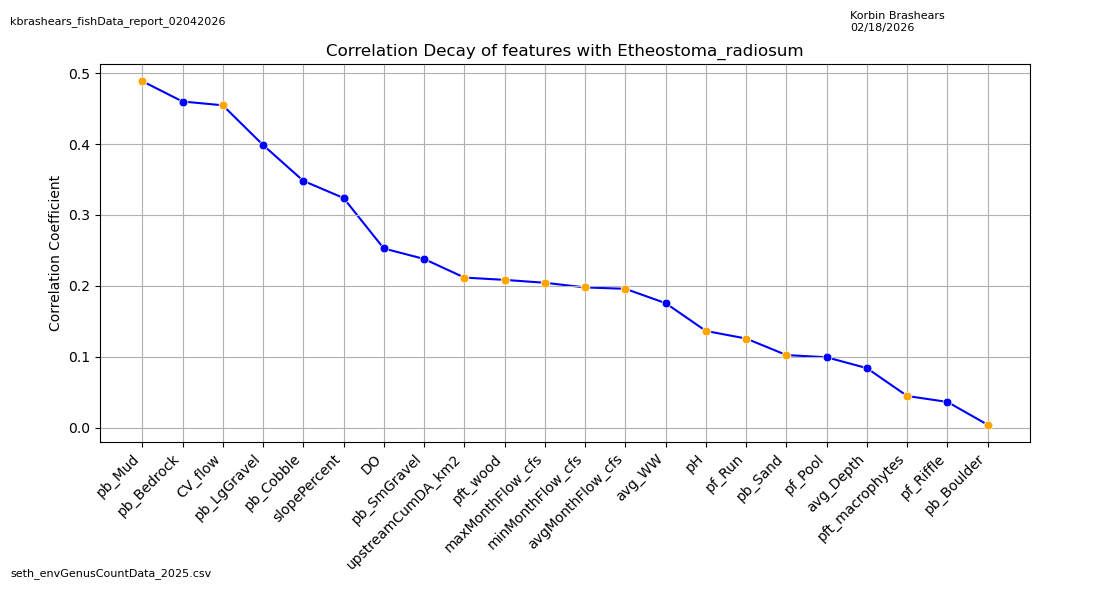

In [ ]:
# Selecting Attribute Columns
att_cols = s_ed.columns[4:]                                                                          # selecting the columns corresponding to environmental attributes

# Correlation Decay Plot
corr_decay_plotter(attribute=s_fcd['Etheostoma_radiosum'], features=s_ed[att_cols], save=False)      # calling the function to create a correlation decay plot for total fish population with environmental attributes

### <a id='toc1_8_4_'></a>[Specific Attribute Trend Lines](#toc0_)

> Plotting a scatter plot and trend line from Etheostoma Radiosum vs Attributes of interest from the last plot.

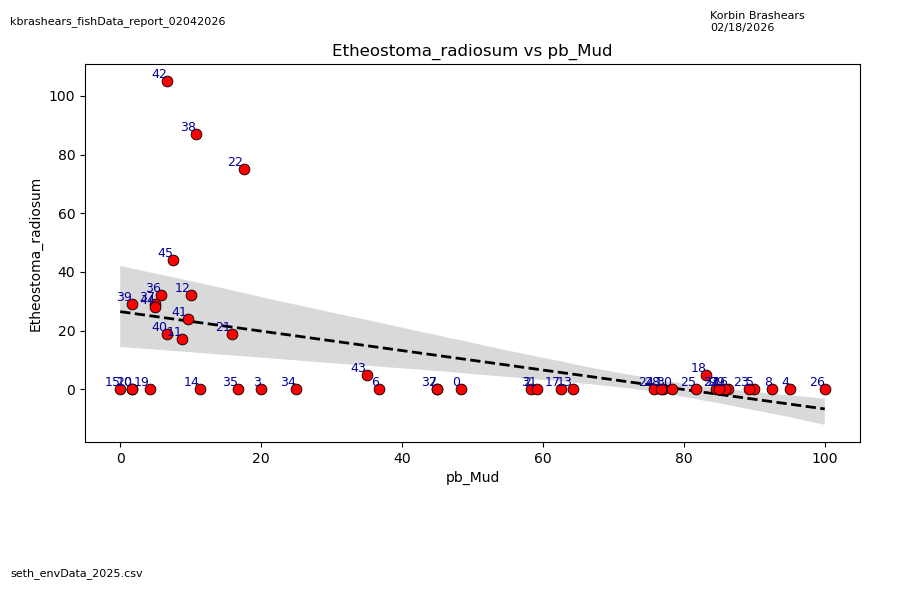

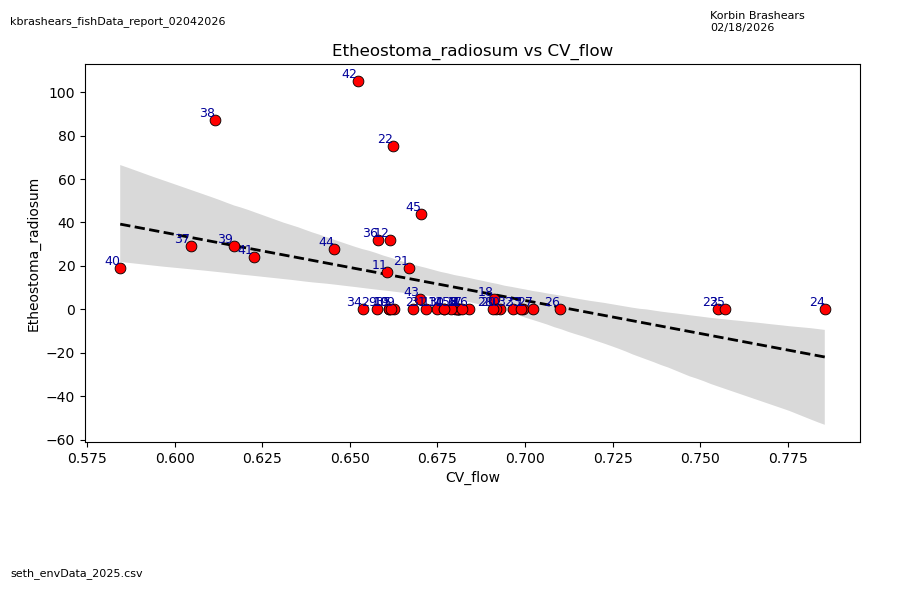

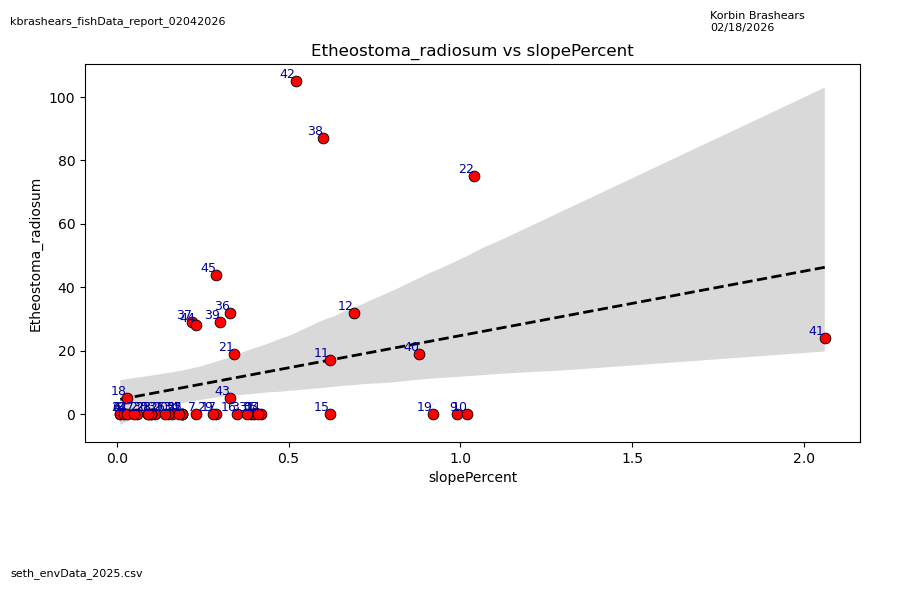

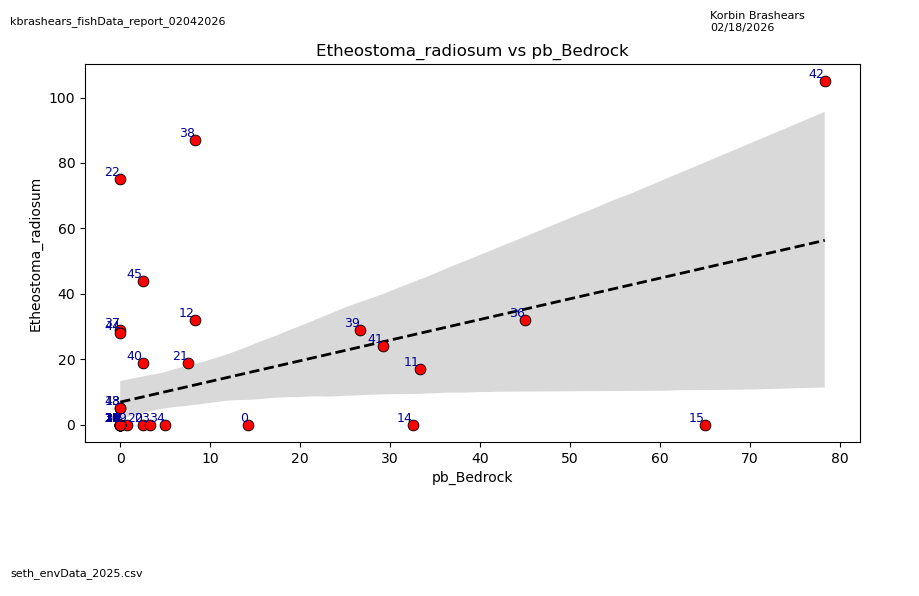

In [ ]:
# pb_Mud
scatter_trendLine_plotter(s_ed['pb_Mud'], s_fcd['Etheostoma_radiosum'], save=False)       # calling the function to create scatter plots of pH

# CV_flow
scatter_trendLine_plotter(s_ed['CV_flow'], s_fcd['Etheostoma_radiosum'], save=False)            # calling the function to create scatter plots of pH

# slopePercent
scatter_trendLine_plotter(s_ed['slopePercent'], s_fcd['Etheostoma_radiosum'], save=False)            # calling the function to create scatter plots of pH

# pb_Bedrock
scatter_trendLine_plotter(s_ed['pb_Bedrock'], s_fcd['Etheostoma_radiosum'], save=False)            # calling the function to create scatter plots of pH

### <a id='toc1_8_5_'></a>[U-MAP Clustering](#toc0_)



c:\Users\Korbin\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


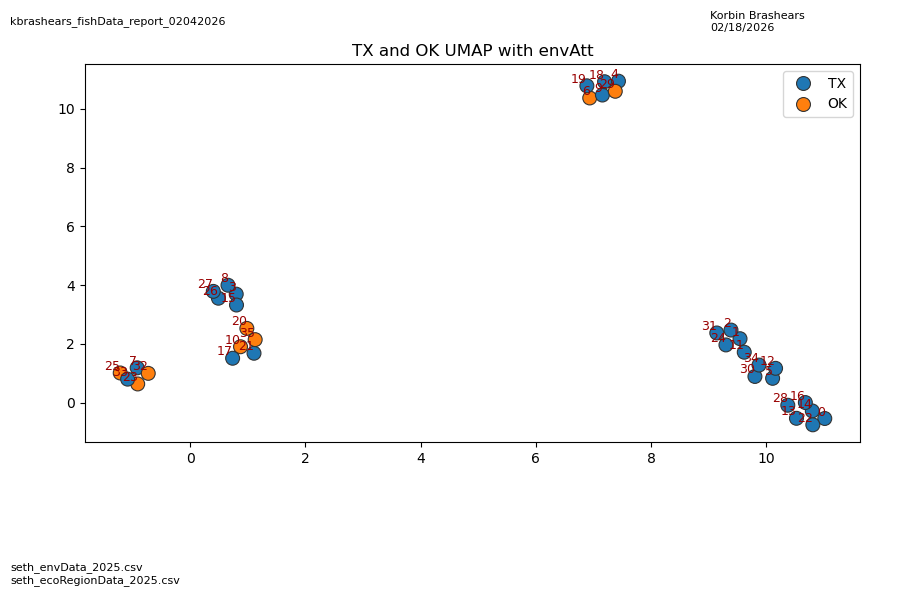

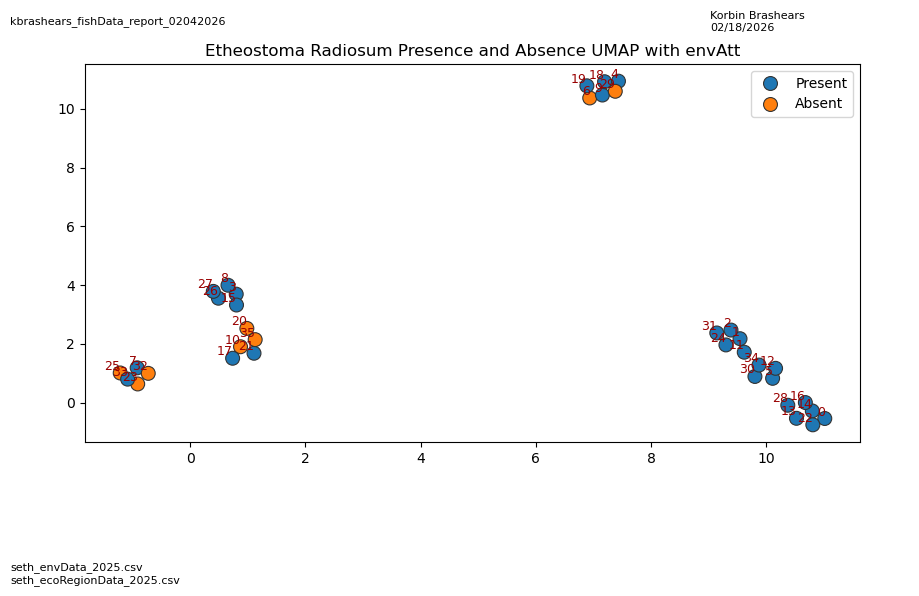

In [ ]:

cf_c = ['pb_Bedrock', 'CV_flow', 'slopePercent']                          # selecting the environmental attribute columns for clustering

X = s_ed[cf_c].copy()                                                     # creating a new data frame with only the environmental attribute columns for clustering

le = LabelEncoder()                                                       # creating an instance of the LabelEncoder for encoding categorical variables
labels = s_erd['State'].astype(str)                                       # selecting the 'SiteN' column as the labels for encoding
y = le.fit_transform(labels)                                              # fitting the label encoder to the labels and transforming them into numerical format

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scalar = StandardScaler()                                                 # creating an instance of the StandardScaler for feature scaling
Xtr = scalar.fit_transform(X_train)                                       # fitting the scaler to the data and transforming it to have zero mean and unit variance
Xte = scalar.transform(X_test)                                            # fitting the scaler to the data and transforming it to have zero mean and unit variance


#----------------------------------------------------------------
# U-MAP Clustering
#----------------------------------------------------------------

umap_model = umap.UMAP(
    n_components=2, metric='correlation', random_state=30,
    n_neighbors=7, n_epochs=700, learning_rate=0.01, min_dist=0.1, n_jobs=2
)      

Xtr_umap = umap_model.fit_transform(Xtr)                                  # fitting the UMAP model to the training data and transforming it to 2 dimensions
Xte_umap = umap_model.transform(Xte)                                      # transforming the test data using the fitted UMAP model  

plt.figure(figsize=(10, 6))                                               # creating the figure for the UMAP plot with matplotlib
sns.scatterplot(x=Xtr_umap[:, 0], y=Xtr_umap[:, 1], hue=le.inverse_transform(y_train), palette='tab10', s=100, edgecolor='#333333')

# Adding Point Index Labels
for i in range(len(Xtr_umap[:, 0])):
    plt.text(Xtr_umap[i, 0], Xtr_umap[i, 1], str(i), fontsize=9, ha='right', va='bottom', color='#990000', zorder=3)       # adding index labels to each point

plt.title('TX and OK UMAP with envAtt')

label_plot_edges(
    program_names="kbrashears_fishData_report_02042026",                # calling the function to label the edges of the plot
    author_names="Korbin Brashears", 
    data_filenames=["seth_envData_2025.csv", "seth_ecoRegionData_2025.csv"], 
    fig_filename="../figures/kbrashears_fishData_report_02042026/TX_OK_envAtt_umap.png",
    save = saveAll if saveAll else False                                # change False to True to save individual figure separately from saveAll
)

plt.show()

# ===================================================== Changing Labels ===========================================================

labels = []
for i in s_fcd['Etheostoma_radiosum']:
    if i > 0:
        labels.append('Present')
    else:
        labels.append('Absent')
y = le.fit_transform(labels)                                              # fitting the label encoder to the labels and transforming them into numerical format

plt.figure(figsize=(10, 6))                                               # creating the figure for the UMAP plot with matplotlib
sns.scatterplot(x=Xtr_umap[:, 0], y=Xtr_umap[:, 1], hue=le.inverse_transform(y_train), palette='tab10', s=100, edgecolor='#333333')

# Adding Point Index Labels
for i in range(len(Xtr_umap[:, 0])):
    plt.text(Xtr_umap[i, 0], Xtr_umap[i, 1], str(i), fontsize=9, ha='right', va='bottom', color='#990000', zorder=3)       # adding index labels to each point

plt.title('Etheostoma Radiosum Presence and Absence UMAP with envAtt')

label_plot_edges(
    program_names="kbrashears_fishData_report_02042026",                # calling the function to label the edges of the plot
    author_names="Korbin Brashears", 
    data_filenames=["seth_envData_2025.csv", "seth_ecoRegionData_2025.csv"], 
    fig_filename="../figures/kbrashears_fishData_report_02042026/etheostomaRadiosum_presenceAbsence_umap.png",
    save = saveAll if saveAll else False                                # change False to True to save individual figure separately from saveAll
) 

plt.show()

### <a id='toc1_8_6_'></a>[KNN Classifier](#toc0_)

> This cell creates a KNN classifier to predict if a site does or does not have Orange Belly Darters.

#### <a id='toc1_8_6_1_'></a>[First Model](#toc0_)

> Creating a starting place model to play with and test KNN with 4-fold CVS, different parameters, and features.
>The results are visualized with various metrics and a confusion matrix.

              precision    recall  f1-score   support

       False       0.82      0.87      0.84        31
        True       0.69      0.60      0.64        15

    accuracy                           0.78        46
   macro avg       0.76      0.74      0.74        46
weighted avg       0.78      0.78      0.78        46



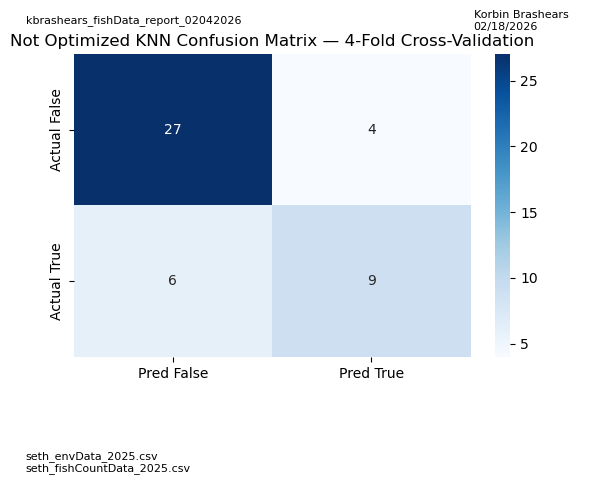

In [ ]:
cf_c = s_ed.columns[4:]                                                   # selecting the environmental attribute columns for clustering
s_ed['has_Etheostoma_radiosum'] = s_fcd['Etheostoma_radiosum'] > 0        # creating a new column in the environmental data frame indicating presence or absence of Etheostoma radiosum

#cf_c = ['pb_Bedrock', 'CV_flow', 'slopePercent']                         # selecting the environmental attribute columns for clustering

X = s_ed[cf_c].copy()                                                     # creating a new data frame with only the environmental attribute columns for clustering
y = s_ed['has_Etheostoma_radiosum'].astype(int)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4-fold stratified CV
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

knn = KNeighborsClassifier(n_neighbors=3)

# Cross-validated predictions
y_pred_cv = cross_val_predict(knn, X_scaled, y, cv=skf)

# Report
print(classification_report(y, y_pred_cv, target_names=['False','True']))

# Confusion matrix
cm = confusion_matrix(y, y_pred_cv)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred False", "Pred True"],
            yticklabels=["Actual False", "Actual True"])
plt.title("Not Optimized KNN Confusion Matrix — 4-Fold Cross-Validation")

label_plot_edges(
    program_names="kbrashears_fishData_report_02042026",                # calling the function to label the edges of the plot
    author_names="Korbin Brashears", 
    data_filenames=["seth_envData_2025.csv", "seth_fishCountData_2025.csv"], 
    fig_filename="../figures/kbrashears_fishData_report_02042026/KNN_etheostomaRadiosum_notOptimized.png",
    save = saveAll if saveAll else False                                # change False to True to save individual figure separately from saveAll
)

plt.show()

#### <a id='toc1_8_6_2_'></a>[Determining the Best Parameters for the KNN](#toc0_)

>  Creating a for loop to test and compare various parameters for the KNN model and determine the most accurate combination.

In [ ]:
cf_c = s_ed.columns[4:]                                                   # selecting the environmental attribute columns for clustering
s_ed['has_Etheostoma_radiosum'] = s_fcd['Etheostoma_radiosum'] > 0       # creating a new column in the environmental data frame indicating presence or absence of Etheostoma radiosum

#cf_c = ['pb_Bedrock', 'CV_flow', 'slopePercent']                          # selecting the environmental attribute columns for clustering

X = s_ed[cf_c].copy()                                                     # creating a new data frame with only the environmental attribute columns for clustering
y = s_ed['has_Etheostoma_radiosum'].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

best_model = None
best_recall = -1
best_params = None

for k in range(1, 16):
    for w in ['uniform', 'distance']:
        for metric in ['euclidean', 'manhattan']:
            
            knn = KNeighborsClassifier(
                n_neighbors=k,
                weights=w,
                metric=metric
            )
            
            y_pred_cv = cross_val_predict(knn, X_scaled, y, cv=skf)
            report = classification_report(y, y_pred_cv, output_dict=True)
            
            recall_true = report['1']['recall']  # recall for presence
            
            if recall_true > best_recall:
                best_recall = recall_true
                best_model = knn
                best_params = (k, w, metric)

print("Best parameters:", best_params)
print("Best recall for TRUE:", best_recall)

Best parameters: (10, 'distance', 'manhattan')
Best recall for TRUE: 0.8666666666666667


#### <a id='toc1_8_6_3_'></a>[Performing KNN With the Best Parameters](#toc0_)

> Using the previously determined "Best" parameters of (10, 'distance', 'manhattan') in our KNN-model.

              precision    recall  f1-score   support

       False       0.94      0.94      0.94        31
        True       0.87      0.87      0.87        15

    accuracy                           0.91        46
   macro avg       0.90      0.90      0.90        46
weighted avg       0.91      0.91      0.91        46



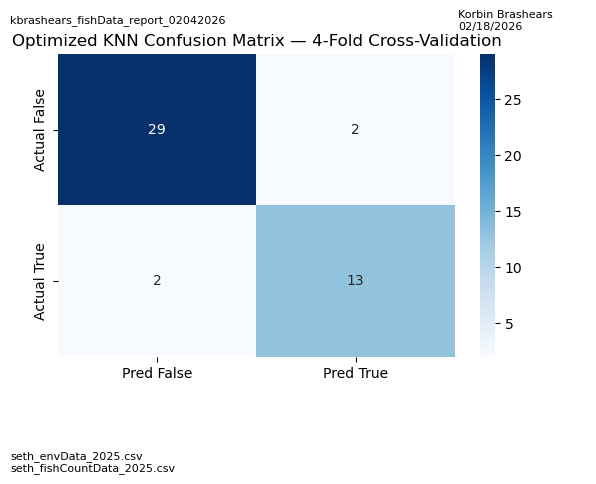

In [ ]:
cf_c = s_ed.columns[4:]                                                   # selecting the environmental attribute columns for clustering
s_ed['has_Etheostoma_radiosum'] = s_fcd['Etheostoma_radiosum'] > 0       # creating a new column in the environmental data frame indicating presence or absence of Etheostoma radiosum

#cf_c = ['pb_Bedrock', 'CV_flow', 'slopePercent']                          # selecting the environmental attribute columns for clustering

X = s_ed[cf_c].copy()                                                     # creating a new data frame with only the environmental attribute columns for clustering
y = s_ed['has_Etheostoma_radiosum'].astype(int)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4-fold stratified CV
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
knn = KNeighborsClassifier(n_neighbors=10, weights='distance', metric='manhattan')

# Cross-validated predictions
y_pred_cv = cross_val_predict(knn, X_scaled, y, cv=skf)

# Report
print(classification_report(y, y_pred_cv, target_names=['False','True']))

# Confusion matrix
cm = confusion_matrix(y, y_pred_cv)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred False", "Pred True"],
            yticklabels=["Actual False", "Actual True"])
plt.title("Optimized KNN Confusion Matrix — 4-Fold Cross-Validation")

label_plot_edges(
    program_names="kbrashears_fishData_report_02042026",                # calling the function to label the edges of the plot
    author_names="Korbin Brashears", 
    data_filenames=["seth_envData_2025.csv", "seth_fishCountData_2025.csv"], 
    fig_filename="../figures/kbrashears_fishData_report_02042026/KNN_etheostomaRadiosum_Optimized.png",
    save = saveAll if saveAll else False                                # change False to True to save individual figure separately from saveAll
)

plt.show()

## <a id='toc1_9_'></a>[A Focus on Nototropis](#toc0_)

In [ ]:

cf_c = ['pb_Bedrock', 'CV_flow', 'slopePercent']                          # selecting the environmental attribute columns for clustering

X = s_ed[cf_c].copy()                                                     # creating a new data frame with only the environmental attribute columns for clustering

le = LabelEncoder()                                                       # creating an instance of the LabelEncoder for encoding categorical variables
labels = []
for i in s_gcd['Nototropis']:
    if i > 0:
        labels.append('Present')
    else:
        labels.append('Absent')
y = le.fit_transform(labels)                                                # fitting the label encoder to the labels and transforming them into numerical format

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scalar = StandardScaler()                                                 # creating an instance of the StandardScaler for feature scaling
Xtr = scalar.fit_transform(X_train)                                       # fitting the scaler to the data and transforming it to have zero mean and unit variance
Xte = scalar.transform(X_test)                                            # fitting the scaler to the data and transforming it to have zero mean and unit variance


#----------------------------------------------------------------
# U-MAP Clustering
#----------------------------------------------------------------

umap_model = umap.UMAP(
    n_components=2, metric='correlation', random_state=30,
    n_neighbors=7, n_epochs=700, learning_rate=0.01, min_dist=0.1, n_jobs=2
)      

Xtr_umap = umap_model.fit_transform(Xtr)                                  # fitting the UMAP model to the training data and transforming it to 2 dimensions
Xte_umap = umap_model.transform(Xte)                                      # transforming the test data using the fitted UMAP model  

plt.figure(figsize=(10, 6))                                               # creating the figure for the UMAP plot with matplotlib
sns.scatterplot(x=Xtr_umap[:, 0], y=Xtr_umap[:, 1], hue=le.inverse_transform(y_train), palette='tab10', s=100, edgecolor='#333333')

# Adding Point Index Labels
for i in range(len(Xtr_umap[:, 0])):
    plt.text(Xtr_umap[i, 0], Xtr_umap[i, 1], str(i), fontsize=9, ha='right', va='bottom', color='#990000', zorder=3)       # adding index labels to each point

plt.title('Nototropis Presence and Absence UMAP with envAtt')

label_plot_edges(
    program_names="kbrashears_fishData_report_02042026",                # calling the function to label the edges of the plot
    author_names="Korbin Brashears", 
    data_filenames=["seth_envData_2025.csv", "seth_ecoRegionData_2025.csv"], 
    fig_filename="../figures/kbrashears_fishData_report_02042026/nototropis_presenceAbsence_umap.png",
    save = saveAll if saveAll else False                                # change False to True to save individual figure separately from saveAll
) 

plt.show()

NameError: name 's_ed' is not defined